In [64]:
import scipy.io
from scipy.ndimage import uniform_filter1d
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import torch
import os
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

# Set up plotting
plt.style.use('default')
sns.set_palette("husl")
%matplotlib inline

print("All libraries imported successfully!")

All libraries imported successfully!


In [65]:
# Configuration
current_dir = os.getcwd()
data_path = Path(current_dir, "HX3_LHS_finalData_uniformlhs.mat")
models_dir = Path(current_dir, "Models")

# Column names for reference
col_names = [
    "coolant channel diameter (m)",         # 0
    "HX overall length (m)",                # 1
    "HX overall width (m)",                 # 2
    "Channel height (m)",                   # 3
    "Number of air layers/channels",        # 4
    "Strut Diameter (m)",                   # 5
    "Strut length to diameter ratio",       # 6
    "coolant flow rate (kg/s)",             # 7
    "Air flow rate (kg/s)",                 # 8
    "Area ratio_diff (diffuser exit/inlet)",# 9
    "diffuser half angle (degrees)",        # 10
    "Area ratio_nozz (nozzle inlet/exit)",  # 11
    "nozzle half angle (degrees)",          # 12
    "fan on/off",                           # 13
    "HX weight (kg)",                       # 14
    "HX power (W)",                         # 15
    "Drag (N)",                             # 16
    "Design point (780=Takeoff, 2720=Cruise)", # 17
    "DTAMB (centigrade)",                   # 18
    "T_Bat_in or T_HX_out (centigrade)",    # 19
    "T_HX_in limit (centigrade)",           # 20
    "Heat Load (W)",                        # 21
    "Actual T_HX_in (centigrade)",          # 22
    "porosity",                             # 23
    "air side hydraulic diameter (wrt DP)", # 24
    "HX overall height (m)",                # 25
    "aircraft speed"                        # 26
]
remove_cols = [14, 15, 16, 21, 8, 13, 27, 19,20,17,25,24,23] 
# Target indices for Drag model (Drag, Heat Load, Air flow rate)
y_indices = [16, 21, 8]
target_names = ["Drag (N)", "Heat Load (W)", "Air flow rate (kg/s)"]

print(f"Data path: {data_path}")
print(f"Target outputs: {target_names}")

Data path: c:\Users\abfat\Desktop\HX3_github\HX3_LHS_finalData_uniformlhs.mat
Target outputs: ['Drag (N)', 'Heat Load (W)', 'Air flow rate (kg/s)']


In [66]:
def load_and_preprocess_data():
    """Load and preprocess data exactly as in the Drag training script"""
    # Load data
    data = scipy.io.loadmat(data_path)
    variable_data = data['HXdata']
    print(f"Original data shape: {variable_data.shape}")
    
    # Remove first 2 columns (same as training script)
    variable_data = variable_data[:, 2:]
    
    # Keep only fan-OFF cases (Drag model requirement - OPPOSITE of Weight/Power!)
    fan_on = variable_data[:, 13] == 1
    variable_data = variable_data[~fan_on]
    print(f"num of fan-on rows removed: {np.sum(fan_on)}")

    power_too_high = variable_data[:,15] >= 15000
    weight_too_low = variable_data[:,14] <= 0
    drag_too_low = variable_data[:,16] <= 0

    variable_data = variable_data[~power_too_high & ~weight_too_low & ~drag_too_low]
    print(f"removed {np.sum(power_too_high | weight_too_low | drag_too_low)} rows based on weight/power/drag criteria")



    no_div = variable_data[:, 27] == 0
    variable_data = variable_data[~no_div]
    print(f"num of no-div rows removed: {np.sum(no_div)}")
    
    # Extract inputs and outputs (Drag model removes Air flow rate from inputs since it's an output)
    remove_cols = [14, 15, 16, 21, 8, 13, 27, 19,20,17,25,24,23] 
    x = np.delete(variable_data, remove_cols, axis=1)
    y = variable_data[:, y_indices]
    
    print(f"Final data shape - Inputs: {x.shape}, Outputs: {y.shape}")
    
    return x, y, variable_data

# Load the data
X_data, y_data, full_data = load_and_preprocess_data()

Original data shape: (149999, 30)
num of fan-on rows removed: 75464
removed 14556 rows based on weight/power/drag criteria
num of no-div rows removed: 147
Final data shape - Inputs: (59832, 15), Outputs: (59832, 3)


In [67]:
from models import get_device, TaperedMultiLayerNN

def load_model(model_path):
    """Load a trained model with all its components"""
    device = get_device()
    checkpoint = torch.load(model_path, map_location=device, weights_only=False)
    
    # Extract configuration
    config = checkpoint['config']
    input_size = X_data.shape[1]
    output_size = len(y_indices)  # 3 outputs for Drag model
    
    # Recreate model
    model = TaperedMultiLayerNN(
        input_size=input_size,
        initial_hidden_size=config['hidden_size'],
        output_size=output_size,
        num_layers=config['layers'],
        dropout=0.10
    ).to(device)
    
    # Load state
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()
    
    # Get scalers
    input_scaler = checkpoint['input_scaler']
    output_scaler = checkpoint['output_scaler']
    
    return model, input_scaler, output_scaler, checkpoint

def find_available_models():
    """Find all available Drag models"""
    model_files = []
    
    # Check current directory
    for file in Path(current_dir).glob("D_MLP_*.pth"):
        model_files.append(file)
    
    # Check Models directory if it exists
    if models_dir.exists():
        for file in models_dir.glob("D_MLP_*.pth"):
            model_files.append(file)
    
    return sorted(model_files)

# Find available models
available_models = find_available_models()
print(f"Found {len(available_models)} Drag models:")
for i, model_path in enumerate(available_models):
    print(f"  {i}: {model_path.name}")

Found 6 Drag models:
  0: D_MLP_1024_2.pth
  1: D_MLP_2048_2.pth
  2: D_MLP_3072_3.pth
  3: D_MLP_4096_3.pth
  4: D_MLP_5120_4.pth
  5: D_MLP_6144_4.pth


In [68]:
def calc_derived_features(input_vector):
    """
    Calculate derived engineering features from input parameters.
    
    Args:
        input_vector: numpy array with columns matching the input_names order
                     Expected indices after removal of remove_cols:
                     0: coolant_channel_diameter
                     1: HX_overall_length
                     2: HX_overall_width
                     3: Channel_height
                     4: Number_of_air_layers_channels
                     5: Strut_Diameter
                     6: Strut_length_to_diameter_ratio
                     (and others...)
    
    Returns:
        dict with keys: 'porosity', 'AS_hyd_diam', 'HX_overall_height', 'frontal_area'
    """
    # Extract parameters (indices match the order after remove_cols filtering)
    coolant_channel_diameter = input_vector[0]
    HX_overall_length = input_vector[1]
    HX_overall_width = input_vector[2]
    Channel_height = input_vector[3]
    num_air_layers = input_vector[4]
    Strut_Diameter = input_vector[5]
    Strut_length_to_diameter_ratio = input_vector[6]
    
    # Calculate HX overall height
    hx_overall_height = ((coolant_channel_diameter + 0.003) * (num_air_layers - 1)) + (Channel_height * num_air_layers)
    
    # Calculate channel volume
    channel_volume = HX_overall_length * HX_overall_width * Channel_height
    
    # Calculate unit cell properties
    unit_cell_solid_volume = 0.75 * np.pi * Strut_Diameter**3 * (Strut_length_to_diameter_ratio + 0.667 - 1.25)
    unit_cell_volume = (Strut_length_to_diameter_ratio * Strut_Diameter)**3
    num_unit_cells_per_channel = channel_volume / unit_cell_volume
    
    # Calculate total solid volume and flow volume
    total_solid_volume = num_unit_cells_per_channel * num_air_layers * unit_cell_solid_volume
    flow_volume = (channel_volume * num_air_layers) - total_solid_volume
    
    # Calculate porosity
    porosity = flow_volume / (channel_volume * num_air_layers)
    
    # Calculate A_HT (heat transfer area)
    A_HT = 3 * np.pi * Strut_Diameter**2 * (Strut_length_to_diameter_ratio + (2/np.pi) - 1.5) * num_unit_cells_per_channel * num_air_layers
    
    # Calculate air side hydraulic diameter (dh_p)
    AS_hyd_diam = 4 * porosity * channel_volume * num_air_layers / A_HT
    
    # Calculate frontal area
    frontal_area = HX_overall_width * hx_overall_height
    
    return {
        'porosity': porosity,
        'AS_hyd_diam': AS_hyd_diam,
        'HX_overall_height': hx_overall_height,
        'frontal_area': frontal_area
    }


In [69]:
def evaluate_model(model, input_scaler, output_scaler, X_test, y_test):
    """Evaluate model performance for 3-output Drag model"""
    device = get_device()
    
    # Prepare data
    X_scaled = torch.tensor(input_scaler.transform(X_test), dtype=torch.float32).to(device)
    
    # Predict
    with torch.no_grad():
        y_pred_scaled = model(X_scaled).cpu().numpy()
    
    # Inverse transform predictions
    y_pred = output_scaler.inverse_transform(y_pred_scaled)
    
    # Calculate metrics for each output
    metrics = {}
    for i, target_name in enumerate(target_names):
        r2 = r2_score(y_test[:, i], y_pred[:, i])
        mse = mean_squared_error(y_test[:, i], y_pred[:, i])
        mae = mean_absolute_error(y_test[:, i], y_pred[:, i])
        
        metrics[target_name] = {
            'R2': r2,
            'MSE': mse,
            'MAE': mae,
            'RMSE': np.sqrt(mse)
        }
    
    return y_pred, metrics

def compare_models():
    """Compare all available Drag models"""
    if not available_models:
        print("No models found!")
        return None
    
    # Split data for evaluation (same as training)
    X_train, X_test, y_train, y_test = train_test_split(
        X_data, y_data, test_size=0.20, random_state=42, shuffle=True
    )
    
    results = {}
    
    for model_path in available_models:
        try:
            print(f"\\nEvaluating {model_path.name}...")
            model, input_scaler, output_scaler, checkpoint = load_model(model_path)
            
            # Evaluate on test set
            y_pred, metrics = evaluate_model(model, input_scaler, output_scaler, X_test, y_test)
            
            results[model_path.name] = {
                'model': model,
                'input_scaler': input_scaler,
                'output_scaler': output_scaler,
                'checkpoint': checkpoint,
                'metrics': metrics,
                'predictions': y_pred,
                'test_data': (X_test, y_test)
            }
            
            # Print metrics
            for target_name, target_metrics in metrics.items():
                print(f"  {target_name}:")
                for metric_name, value in target_metrics.items():
                    print(f"    {metric_name}: {value:.4f}")
                    
        except Exception as e:
            print(f"  Error loading {model_path.name}: {e}")
    
    return results

# Compare all models
model_results = compare_models()

\nEvaluating D_MLP_1024_2.pth...
GPU is available. Using GPU.
GPU is available. Using GPU.
  Drag (N):
    R2: 0.9889
    MSE: 35.6878
    MAE: 2.5403
    RMSE: 5.9739
  Heat Load (W):
    R2: 0.9709
    MSE: 10338133.6020
    MAE: 1619.1359
    RMSE: 3215.2968
  Air flow rate (kg/s):
    R2: 0.9910
    MSE: 0.0058
    MAE: 0.0371
    RMSE: 0.0764
\nEvaluating D_MLP_2048_2.pth...
GPU is available. Using GPU.
GPU is available. Using GPU.
  Drag (N):
    R2: 0.9892
    MSE: 34.7818
    MAE: 2.4859
    RMSE: 5.8976
  Heat Load (W):
    R2: 0.9709
    MSE: 10337963.8078
    MAE: 1613.6621
    RMSE: 3215.2704
  Air flow rate (kg/s):
    R2: 0.9913
    MSE: 0.0057
    MAE: 0.0364
    RMSE: 0.0753
\nEvaluating D_MLP_3072_3.pth...
GPU is available. Using GPU.
GPU is available. Using GPU.
  Drag (N):
    R2: 0.9908
    MSE: 29.5373
    MAE: 2.1717
    RMSE: 5.4348
  Heat Load (W):
    R2: 0.9785
    MSE: 7619856.2977
    MAE: 1324.7557
    RMSE: 2760.4087
  Air flow rate (kg/s):
    R2: 0.9935


\nModel Comparison Summary:
------------------------------------------------------------
D_MLP_1024_2.pth: Avg R2 = 0.9836
D_MLP_2048_2.pth: Avg R2 = 0.9838
D_MLP_3072_3.pth: Avg R2 = 0.9876
D_MLP_4096_3.pth: Avg R2 = 0.9877
D_MLP_5120_4.pth: Avg R2 = 0.9898
D_MLP_6144_4.pth: Avg R2 = 0.9899
\nBest model: D_MLP_6144_4.pth (Avg R2: 0.9899)


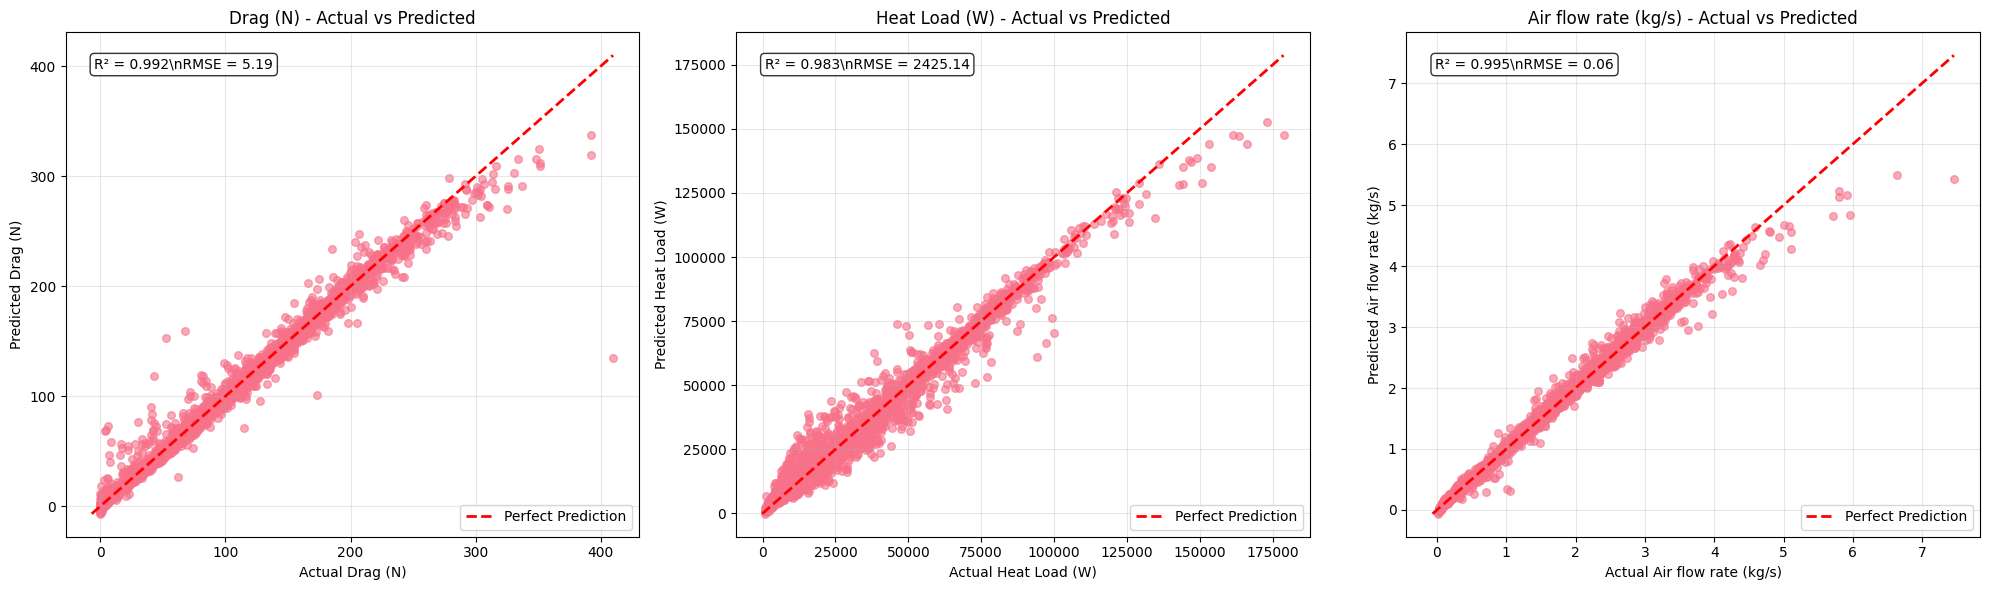

In [70]:
def select_best_model(results):
    """Select best model based on average R2 score"""
    if not results:
        return None, None
    
    best_score = -1
    best_name = None
    
    print("\\nModel Comparison Summary:")
    print("-" * 60)
    
    for name, result in results.items():
        # Calculate average R2
        r2_scores = [metrics['R2'] for metrics in result['metrics'].values()]
        avg_r2 = np.mean(r2_scores)
        
        print(f"{name}: Avg R2 = {avg_r2:.4f}")
        
        if avg_r2 > best_score:
            best_score = avg_r2
            best_name = name
    
    print(f"\\nBest model: {best_name} (Avg R2: {best_score:.4f})")
    return best_name, results[best_name] if best_name else None

def plot_actual_vs_predicted(best_result, save_plots=False):
    """Create actual vs predicted plots for the best 3-output Drag model"""
    if not best_result:
        print("No model results available!")
        return
    
    X_test, y_test = best_result['test_data']
    y_pred = best_result['predictions']
    metrics = best_result['metrics']
    
    # Create 1x3 subplot for 3 outputs
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    
    for i, (target_name, ax) in enumerate(zip(target_names, axes)):
        # Plot actual vs predicted
        ax.scatter(y_test[:, i], y_pred[:, i], alpha=0.6, s=30)
        
        # Perfect prediction line
        min_val = min(y_test[:, i].min(), y_pred[:, i].min())
        max_val = max(y_test[:, i].max(), y_pred[:, i].max())
        ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction')
        
        # Add metrics to plot
        r2 = metrics[target_name]['R2']
        rmse = metrics[target_name]['RMSE']
        ax.text(0.05, 0.95, f'R² = {r2:.3f}\\nRMSE = {rmse:.2f}', 
                transform=ax.transAxes, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
        
        ax.set_xlabel(f'Actual {target_name}')
        ax.set_ylabel(f'Predicted {target_name}')
        ax.set_title(f'{target_name} - Actual vs Predicted')
        ax.legend()
        ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    if save_plots:
        plt.savefig('drag_model_validation.png', dpi=300, bbox_inches='tight')
    
    plt.show()

# Select best model and create validation plots
best_model_name, best_result = select_best_model(model_results)
if best_result:
    plot_actual_vs_predicted(best_result)

Creating parameter sweeps for Drag...
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU i

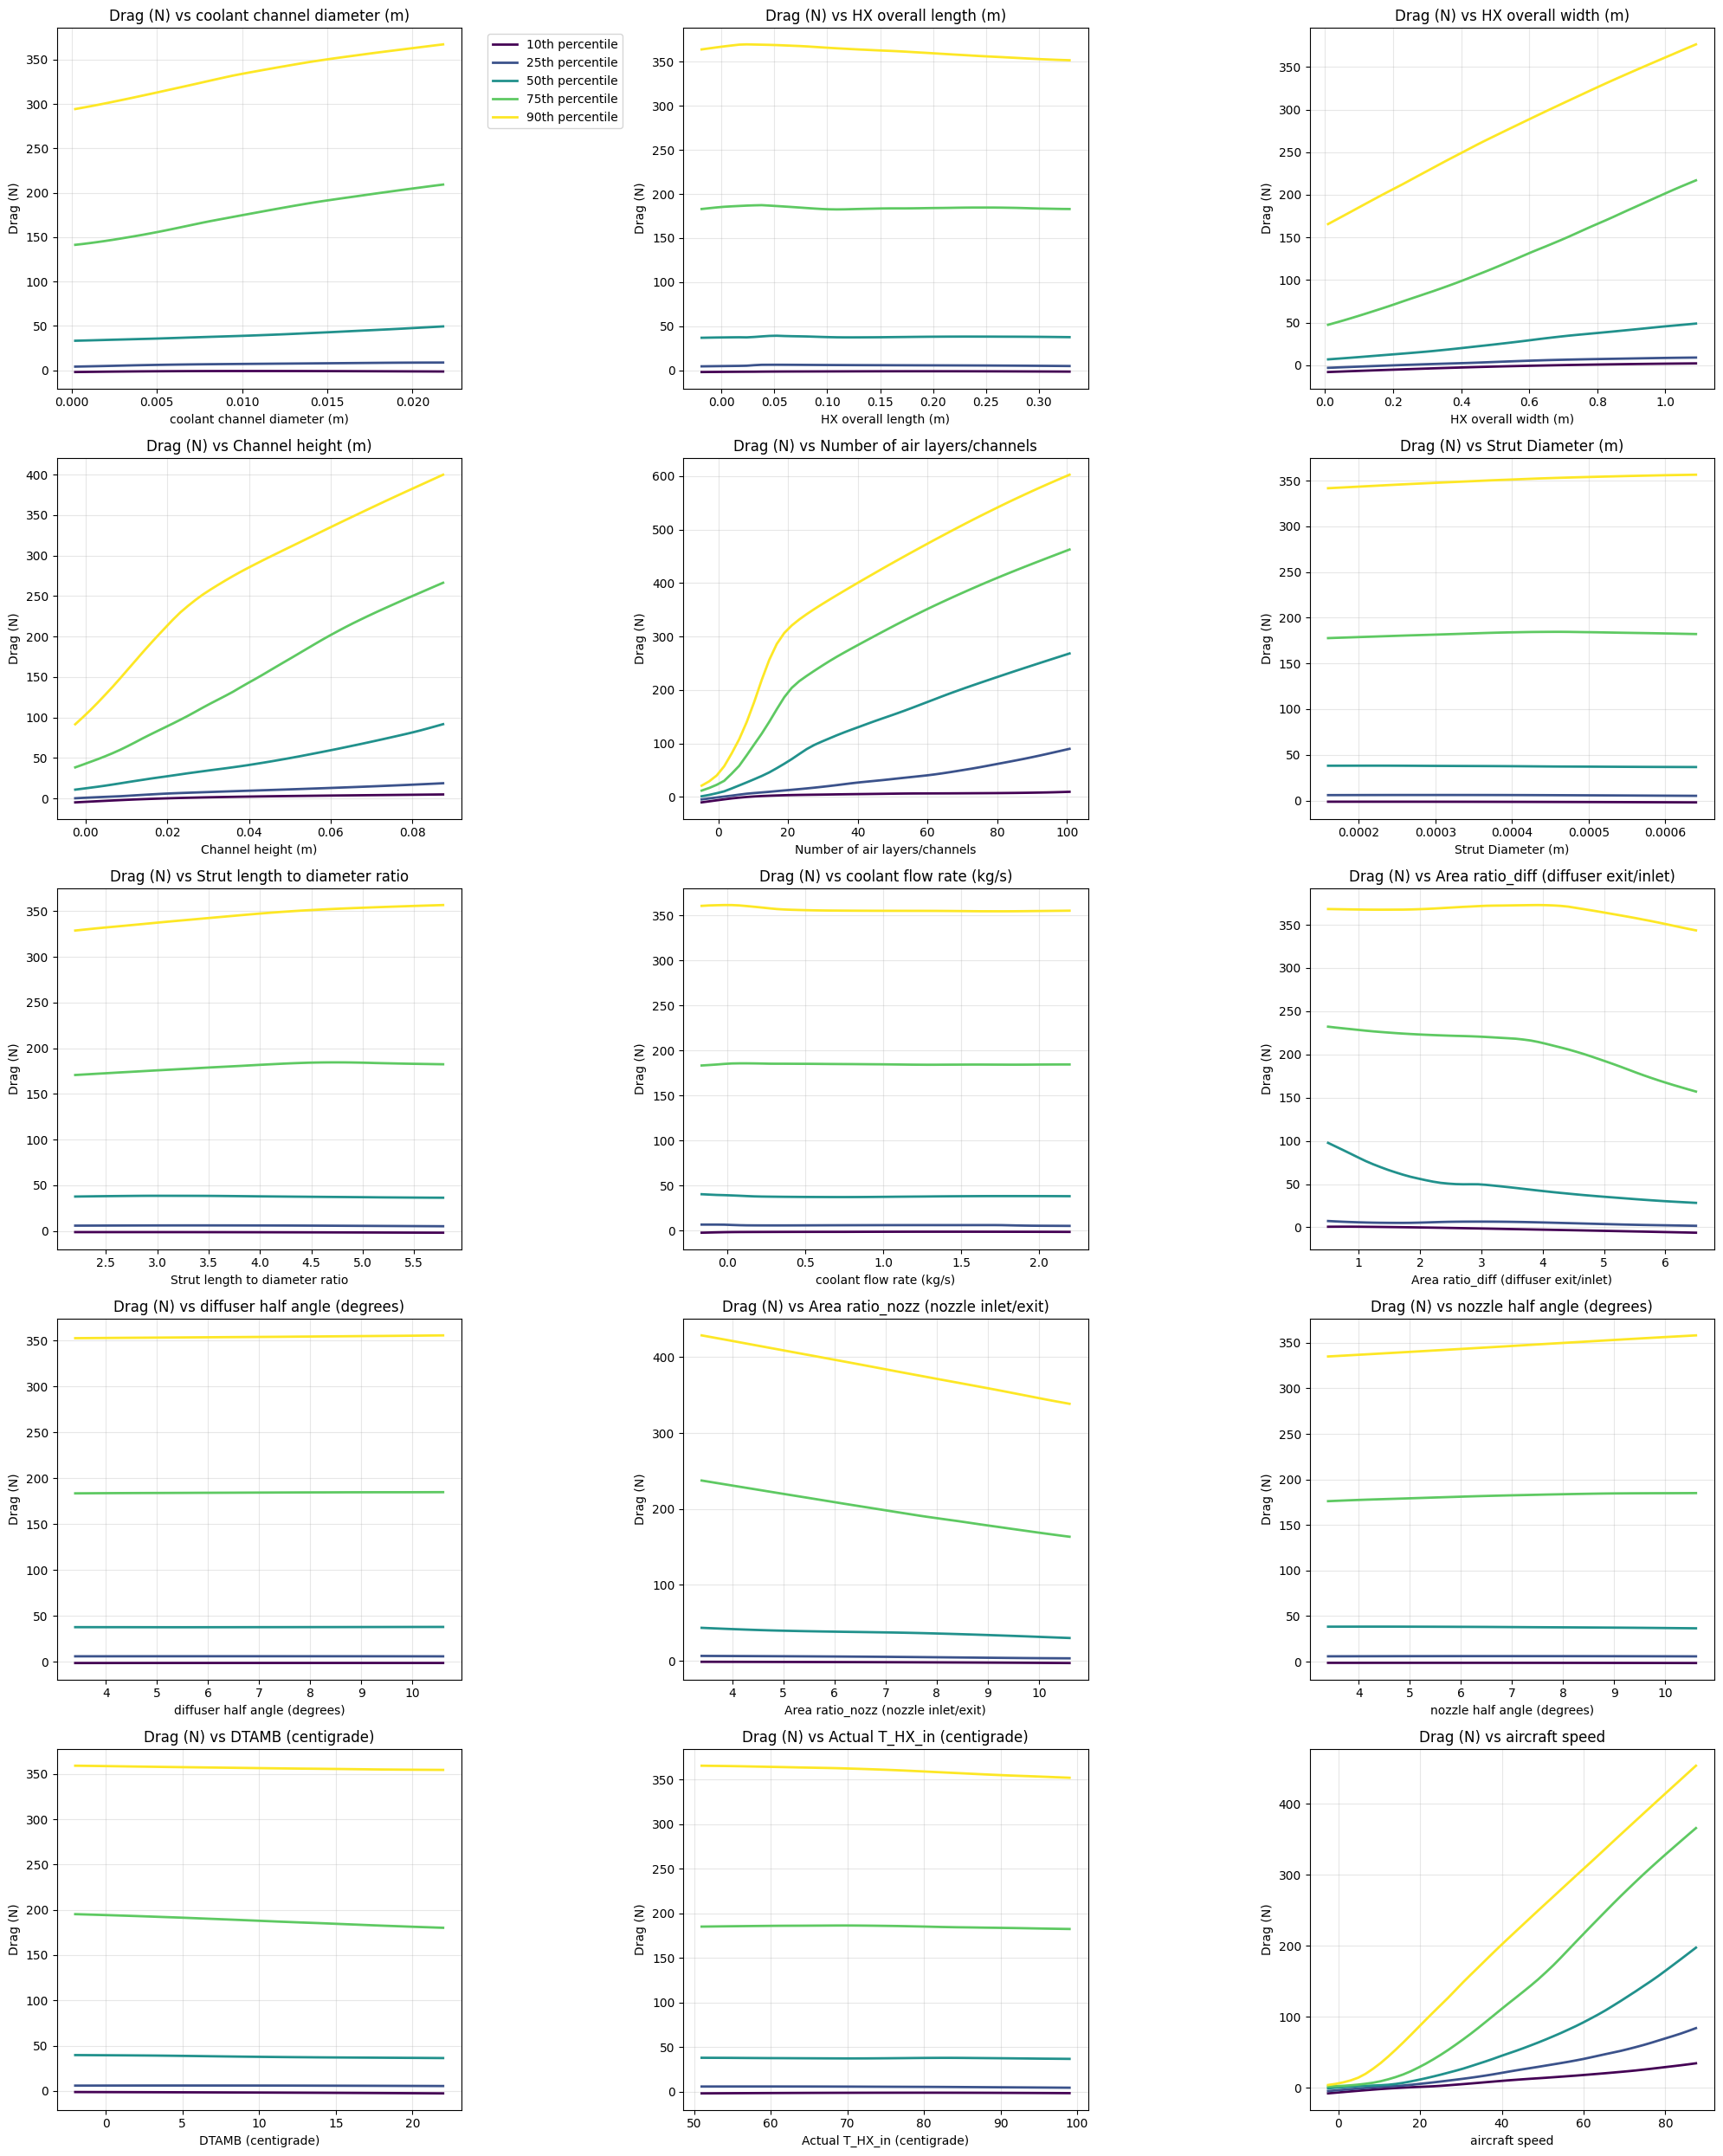

In [71]:
def get_input_names():
    """Get input parameter names after filtering (Drag model excludes Air flow rate)"""
    remove_cols = [14, 15, 16, 21, 8, 13, 27, 19,20,17,25,24,23]
    input_names = [col_names[i] for i in range(len(col_names)) if i not in remove_cols]
    return input_names

def create_baseline_percentiles(X_data, percentiles=[10, 25, 50, 75, 90]):
    """Create baseline values at different percentiles"""
    baselines = {}
    for p in percentiles:
        baselines[f'{p}th percentile'] = np.percentile(X_data, p, axis=0)
    return baselines

def sweep_parameter(model, input_scaler, output_scaler, X_baseline, param_idx, 
                   param_range, param_name, target_idx=0, n_points=50):
    """Sweep a single parameter while keeping others at baseline"""
    device = get_device()
    
    # Create parameter sweep
    param_values = np.linspace(param_range[0], param_range[1], n_points)
    predictions = []
    
    for param_val in param_values:
        # Create input with swept parameter
        X_sweep = X_baseline.copy()
        X_sweep[param_idx] = param_val
        
        # Predict
        X_scaled = torch.tensor(input_scaler.transform(X_sweep.reshape(1, -1)), 
                               dtype=torch.float32).to(device)
        
        with torch.no_grad():
            y_pred_scaled = model(X_scaled).cpu().numpy()
        
        # Inverse transform
        y_pred = output_scaler.inverse_transform(y_pred_scaled)
        predictions.append(y_pred[0, target_idx])
    
    return param_values, np.array(predictions)

def plot_parameter_sweeps(best_result, target_idx=0, save_plots=False):
    """Plot parameter sweeps for all inputs at different percentiles"""
    if not best_result:
        print("No model results available!")
        return
    
    model = best_result['model']
    input_scaler = best_result['input_scaler']
    output_scaler = best_result['output_scaler']
    
    input_names = get_input_names()
    target_name = target_names[target_idx]
    
    # Create baselines at different percentiles
    percentiles = [10, 25, 50, 75, 90]
    baselines = create_baseline_percentiles(X_data, percentiles)
    
    # Calculate number of subplots needed
    n_params = len(input_names)
    n_cols = 3
    n_rows = (n_params + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5*n_rows))
    if n_rows == 1:
        axes = axes.reshape(1, -1)
    
    colors = plt.cm.viridis(np.linspace(0, 1, len(percentiles)))
    
    for i, param_name in enumerate(input_names):
        row = i // n_cols
        col = i % n_cols
        ax = axes[row, col]
        
        # Get parameter range (expand by 20% around data range)
        param_min = X_data[:, i].min()
        param_max = X_data[:, i].max()
        param_range = [param_min - 0.1*(param_max-param_min), 
                      param_max + 0.1*(param_max-param_min)]
        
        # Plot sweeps for each percentile baseline
        for p_idx, (percentile_name, baseline) in enumerate(baselines.items()):
            param_vals, predictions = sweep_parameter(
                model, input_scaler, output_scaler, baseline, i, 
                param_range, param_name, target_idx
            )
            
            ax.plot(param_vals, predictions, 
                   color=colors[p_idx], label=percentile_name, linewidth=2)
        
        ax.set_xlabel(param_name)
        ax.set_ylabel(target_name)
        ax.set_title(f'{target_name} vs {param_name}')
        ax.grid(True, alpha=0.3)
        if i == 0:  # Only add legend to first subplot
            ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    
    # Remove empty subplots
    for i in range(n_params, n_rows * n_cols):
        row = i // n_cols
        col = i % n_cols
        fig.delaxes(axes[row, col])
    
    plt.tight_layout()
    
    if save_plots:
        plt.savefig(f'{target_name.lower().replace(" ", "_").replace("(", "").replace(")", "")}_parameter_sweeps.png', 
                   dpi=300, bbox_inches='tight')
    
    plt.show()

# Create parameter sweeps for all 3 outputs
if best_result:
    print("Creating parameter sweeps for Drag...")
    plot_parameter_sweeps(best_result, target_idx=0)  # Drag

Creating parameter sweeps for Heat Load...
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.


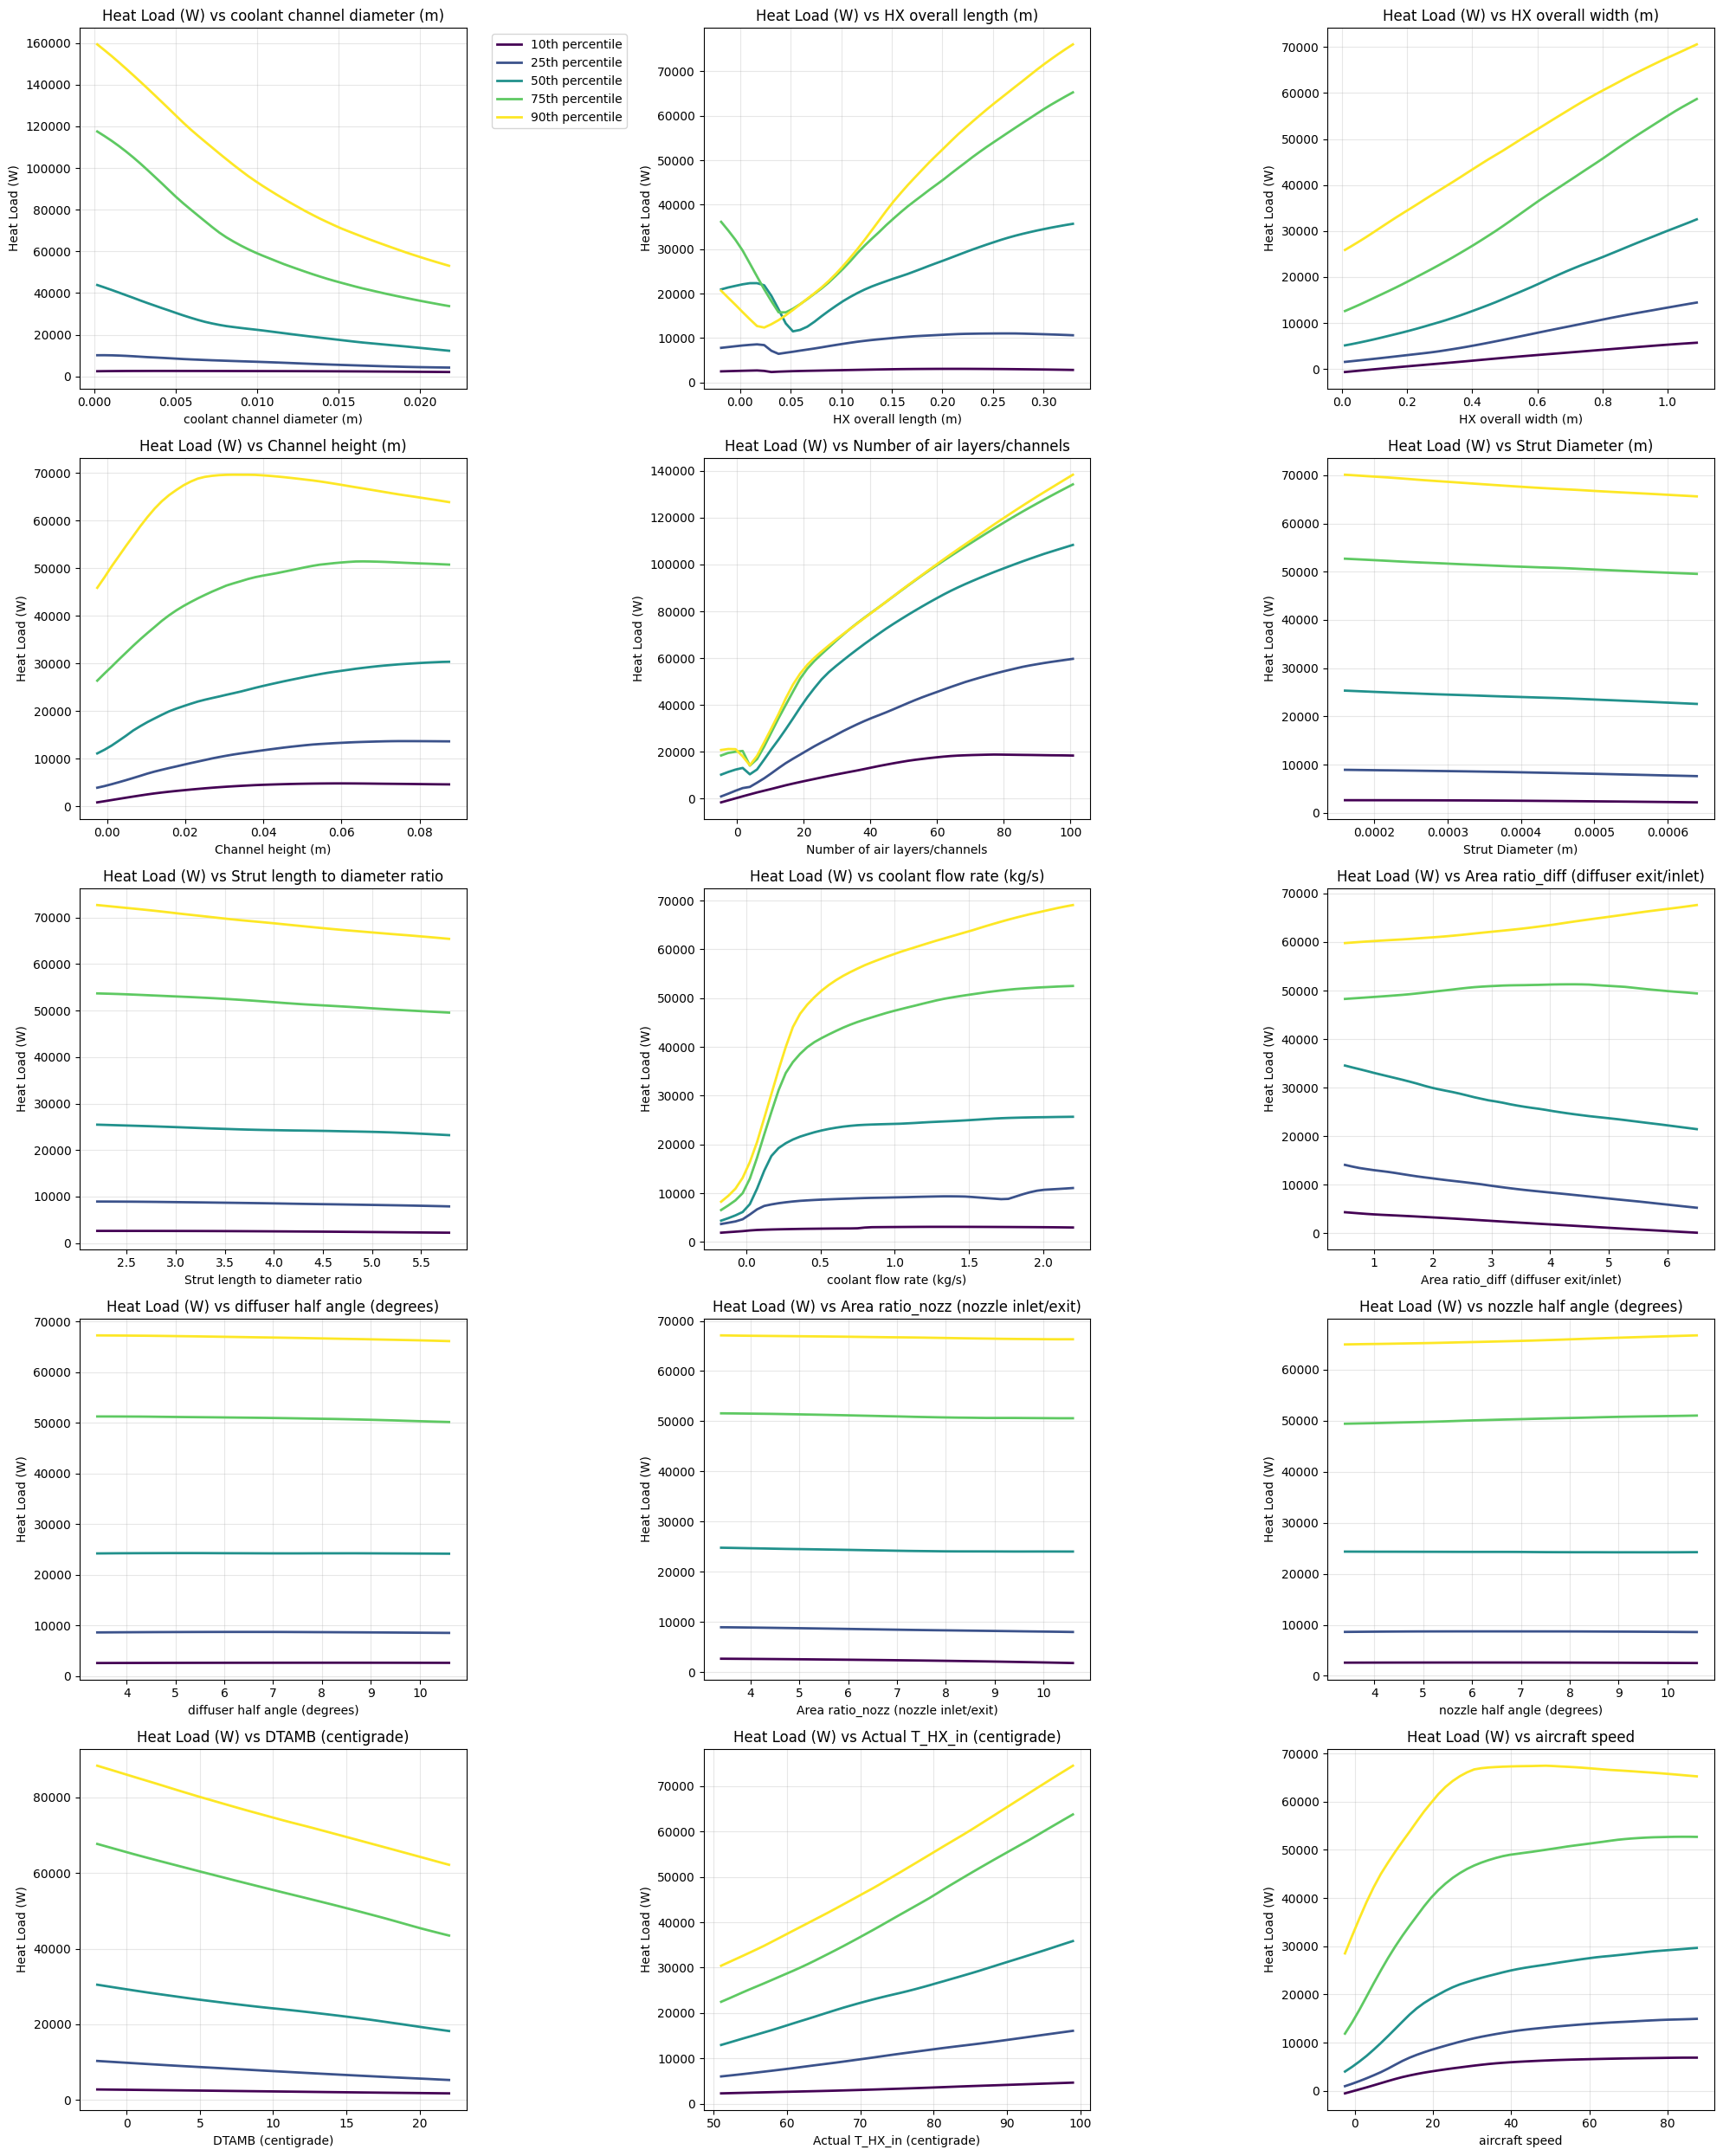

In [72]:
# Create parameter sweeps for Heat Load
if best_result:
    print("Creating parameter sweeps for Heat Load...")
    plot_parameter_sweeps(best_result, target_idx=1)  # Heat Load

Creating parameter sweeps for Heat Load...
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.


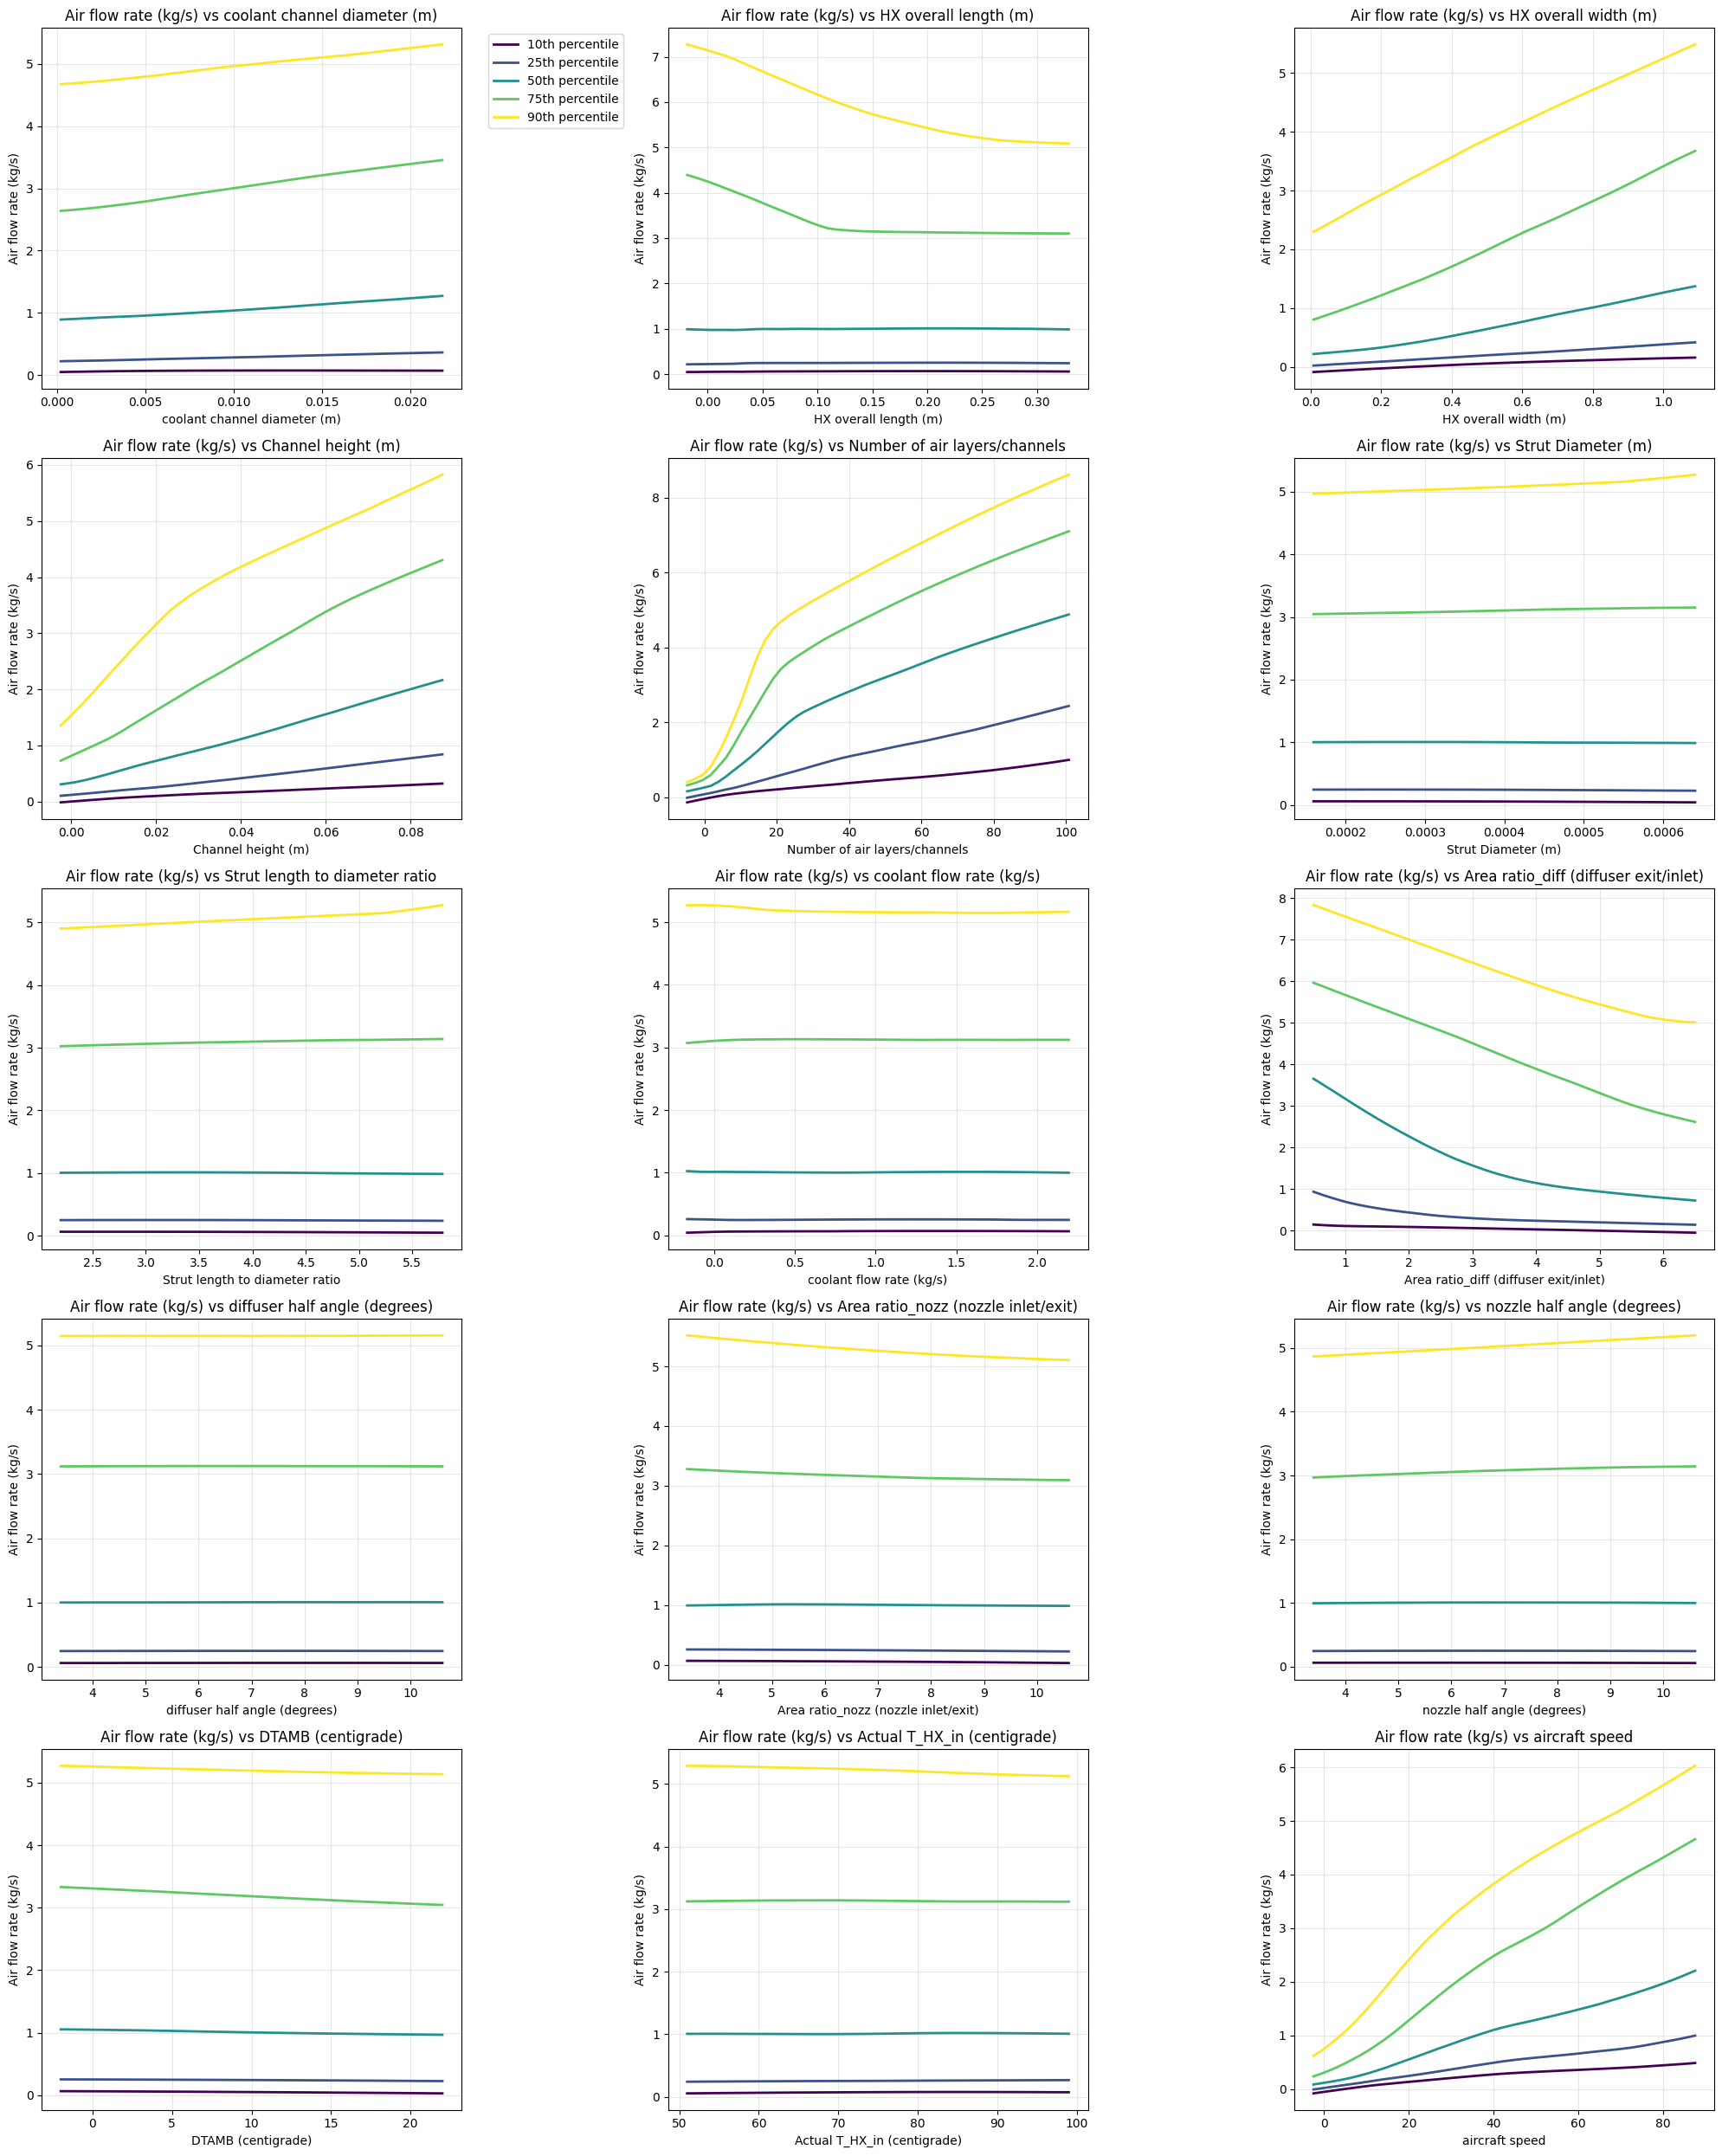

In [73]:
# Create parameter sweeps for Heat Load
if best_result:
    print("Creating parameter sweeps for Heat Load...")
    plot_parameter_sweeps(best_result, target_idx=2)  # Heat Load

In [74]:
# import numpy as np
# import torch
# import matplotlib.pyplot as plt

# """
# Sweep air flow rate from 5th to 95th percentile. For each target, start from previous solution and iteratively adjust inputs in small steps, guided by the gradient of air flow rate wrt inputs, limiting input changes to avoid unrealistic designs.
# """
# def plot_drag_vs_airflow_smooth(best_result, X_data, y_data, n_points=20, max_step=0.05, tol=1e-2, max_iter=100, plot=True,max=None):
#     device = get_device()
#     model = best_result['model']
#     input_scaler = best_result['input_scaler']
#     output_scaler = best_result['output_scaler']
#     # Air flow rate sweep range
#     min_flow = np.percentile(y_data[:,2], 5)
#     # max_flow = np.percentile(y_data[:,2], 99)
#     if max is not None:
#         max_flow = max
#     else:
#         max_flow = np.max(y_data[:,2])
#     max_flow  # Use full max to explore high flow rates
#     airflows = np.linspace(min_flow, max_flow, n_points)
#     drags = []
#     # Start from median input
#     x_prev = np.percentile(X_data, 50, axis=0)
#     for target in airflows:
#         x = x_prev.copy()
#         for _ in range(max_iter):
#             X_scaled = input_scaler.transform(x.reshape(1, -1))
#             X_tensor = torch.tensor(X_scaled, dtype=torch.float32, device=device)
#             X_tensor.requires_grad_(True)
#             y_scaled = model(X_tensor)
#             y = output_scaler.inverse_transform(y_scaled.detach().cpu().numpy())[0]
#             err = y[2] - target
#             if abs(err) < tol:
#                 break
#             # Compute gradient wrt inputs
#             y_scaled[0,2].backward()
#             grad = X_tensor.grad.detach().cpu().numpy()[0]
#             # Take a small step in direction to increase/decrease air flow
#             step = -np.sign(err) * grad * max_step
#             # Limit step size for each input
#             step = np.clip(step, -max_step, max_step)
#             X_scaled_new = X_scaled + step
#             x_new = input_scaler.inverse_transform(X_scaled_new)[0]
#             # Prevent unrealistic values by clamping to 2nd-98th percentile of each input
#             for j in range(len(x_new)):
#                 low = np.percentile(X_data[:,j], 2)
#                 high = np.percentile(X_data[:,j], 98)
#                 x_new[j] = np.clip(x_new[j], low, high)
#             x = x_new
#         # After convergence, record drag
#         X_scaled = input_scaler.transform(x.reshape(1, -1))
#         X_tensor = torch.tensor(X_scaled, dtype=torch.float32, device=device)
#         with torch.no_grad():
#             y_scaled = model(X_tensor).cpu().numpy()
#         y = output_scaler.inverse_transform(y_scaled)[0]
#         drags.append(y[0])
#         x_prev = x  # Use current solution as next starting point
#     if plot:
#         plt.figure(figsize=(8,5))
#         plt.plot(airflows, drags, '-o', alpha=0.8)
#         plt.xlabel('Air flow rate (kg/s)')
#         plt.ylabel('Drag (N)')
#         plt.title('Drag vs Air flow rate (smooth, model-guided sweep)')
#         plt.grid(True, alpha=0.3)
#         plt.tight_layout()
#         plt.show()
#     return airflows, drags

# # Example run
# if best_result:
#     plot_drag_vs_airflow_smooth(best_result, X_data, y_data, n_points=50, max_step=0.03, tol=0.001, max_iter=1000, plot=True, max = 10)


In [75]:
# # Drag vs Engineering Feature Sweeps (HX3 Specific - Simultaneous Input Sweeps)
# import numpy as np
# import torch
# import matplotlib.pyplot as plt

# def _x_idx(name):
#     """Get index of input parameter in X_data"""
#     input_names = get_input_names()
#     name_to_idx = {n: i for i, n in enumerate(input_names)}
#     if name not in name_to_idx:
#         raise KeyError(f"Input '{name}' not in Drag model inputs")
#     return name_to_idx[name]

# def _compute_hx3_derived_features(input_vector):
#     """
#     Compute HX3 derived features using the exact formulas from calc_derived_features.
    
#     Input vector indices (after remove_cols filtering):
#     0: coolant_channel_diameter, 1: HX_overall_length, 2: HX_overall_width
#     3: Channel_height, 4: Number_of_air_layers_channels, 5: Strut_Diameter
#     6: Strut_length_to_diameter_ratio, ...
#     """
#     coolant_channel_diameter = input_vector[0]
#     HX_overall_length = input_vector[1] 
#     HX_overall_width = input_vector[2]
#     Channel_height = input_vector[3]
#     num_air_layers = input_vector[4]
#     Strut_Diameter = input_vector[5]
#     Strut_length_to_diameter_ratio = input_vector[6]
    
#     # HX overall height - depends on coolant_channel_diameter, num_air_layers, Channel_height
#     hx_overall_height = ((coolant_channel_diameter + 0.003) * (num_air_layers - 1)) + (Channel_height * num_air_layers)
    
#     # Frontal area - depends on HX_overall_width and hx_overall_height (indirect: coolant_channel_diameter, num_air_layers, Channel_height)
#     frontal_area = HX_overall_width * hx_overall_height
    
#     # Channel volume - depends on HX_overall_length, HX_overall_width, Channel_height
#     channel_volume = HX_overall_length * HX_overall_width * Channel_height
    
#     # Unit cell properties - depend on Strut_Diameter, Strut_length_to_diameter_ratio
#     unit_cell_solid_volume = 0.75 * np.pi * Strut_Diameter**3 * (Strut_length_to_diameter_ratio + 0.667 - 1.25)
#     unit_cell_volume = (Strut_length_to_diameter_ratio * Strut_Diameter)**3
#     num_unit_cells_per_channel = channel_volume / unit_cell_volume
    
#     # Flow volume - depends on all above parameters
#     total_solid_volume = num_unit_cells_per_channel * num_air_layers * unit_cell_solid_volume
#     flow_volume = (channel_volume * num_air_layers) - total_solid_volume
    
#     # Porosity - depends on flow_volume and channel_volume (indirect: all geometry parameters)
#     porosity = flow_volume / (channel_volume * num_air_layers)
    
#     # Heat transfer area - depends on Strut_Diameter, Strut_length_to_diameter_ratio, num_unit_cells_per_channel, num_air_layers
#     A_HT = 3 * np.pi * Strut_Diameter**2 * (Strut_length_to_diameter_ratio + (2/np.pi) - 1.5) * num_unit_cells_per_channel * num_air_layers
    
#     # AS hydraulic diameter - depends on porosity, channel_volume, num_air_layers, A_HT (indirect: all parameters)
#     AS_hyd_diam = 4 * porosity * channel_volume * num_air_layers / A_HT
    
#     return {
#         'porosity': porosity,
#         'AS_hyd_diam': AS_hyd_diam, 
#         'frontal_area': frontal_area
#     }

# def sweep_drag_vs_hx3_feature_together(
#     best_result,
#     feature='frontal_area',              # 'frontal_area' | 'AS_hyd_diam' | 'porosity'
#     percentiles=(25, 50, 75),
#     n_points=60,
#     show_plot=True,
# ):
#     """
#     Sweep HX3 derived features by simultaneously varying all contributing inputs.
    
#     For each feature, identify the key inputs and sweep them together:
#     - frontal_area: HX_overall_width, coolant_channel_diameter, Channel_height, num_air_layers
#     - porosity: All geometry parameters (most complex dependencies)
#     - AS_hyd_diam: All geometry parameters (depends on porosity and A_HT)
#     """
#     if not best_result:
#         print("No model available")
#         return None
        
#     device = get_device()
#     model = best_result['model']
#     input_scaler = best_result['input_scaler']
#     output_scaler = best_result['output_scaler']
    
#     # Get input indices
#     try:
#         ccd_i = _x_idx("coolant channel diameter (m)")      # 0
#         hx_len_i = _x_idx("HX overall length (m)")          # 1  
#         hx_width_i = _x_idx("HX overall width (m)")         # 2
#         ch_height_i = _x_idx("Channel height (m)")          # 3
#         num_layers_i = _x_idx("Number of air layers/channels")  # 4
#         strut_diam_i = _x_idx("Strut Diameter (m)")         # 5
#         strut_ratio_i = _x_idx("Strut length to diameter ratio") # 6
#     except KeyError as e:
#         print(f"Missing required input: {e}")
#         return None
    
#     # Define which inputs to sweep for each feature
#     if feature == 'frontal_area':
#         # Primary: width, Secondary: height contributors (coolant diameter, layers, channel height)
#         sweep_indices = [hx_width_i, ccd_i, ch_height_i, num_layers_i]
#         feature_name = "HX frontal area"
#         feature_unit = "(m²)"
#     elif feature == 'porosity':
#         # All geometric parameters affect porosity
#         sweep_indices = [hx_len_i, hx_width_i, ch_height_i, num_layers_i, strut_diam_i, strut_ratio_i]
#         feature_name = "Porosity"
#         feature_unit = "(-)"
#     elif feature == 'AS_hyd_diam':
#         # All geometric parameters (through porosity and A_HT)
#         sweep_indices = [hx_len_i, hx_width_i, ch_height_i, num_layers_i, strut_diam_i, strut_ratio_i]
#         feature_name = "AS hydraulic diameter" 
#         feature_unit = "(m)"
#     else:
#         raise ValueError(f"Unknown feature: {feature}")
    
#     # Get percentile ranges for swept parameters
#     param_ranges = {}
#     for idx in sweep_indices:
#         p5, p95 = np.percentile(X_data[:, idx], [5, 95])
#         param_ranges[idx] = (p5, p95)
    
#     colors = plt.cm.viridis(np.linspace(0, 1, len(percentiles)))
#     results = {"feature": feature, "curves": {}}
    
#     if show_plot:
#         plt.figure(figsize=(10, 6))
    
#     for c, p in zip(colors, percentiles):
#         x_base = np.percentile(X_data, p, axis=0)
        
#         eng_vals = []
#         drags = []
        
#         for frac in np.linspace(0, 1, n_points):
#             x_mod = x_base.copy()
            
#             # Sweep all relevant parameters together
#             for idx in sweep_indices:
#                 p5, p95 = param_ranges[idx]
#                 new_val = p5 + frac * (p95 - p5)
#                 x_mod[idx] = new_val
            
#             # Compute derived feature using HX3 formulas
#             derived_features = _compute_hx3_derived_features(x_mod)
#             feature_val = derived_features[feature]
#             eng_vals.append(feature_val)
            
#             # Predict drag
#             X_scaled = input_scaler.transform(x_mod.reshape(1, -1))
#             with torch.no_grad():
#                 y_scaled = model(torch.tensor(X_scaled, dtype=torch.float32, device=device)).cpu().numpy()
#             y = output_scaler.inverse_transform(y_scaled)[0]
#             drags.append(float(y[0]))
        
#         eng_vals = np.array(eng_vals)
#         drags = np.array(drags)
#         results['curves'][f'p{p}'] = {'eng': eng_vals, 'drag': drags}
        
#         if show_plot:
#             label = f"{p}th percentile baseline"
#             plt.plot(eng_vals, drags, color=c, label=label, linewidth=2)
    
#     if show_plot:
#         plt.xlabel(f'{feature_name} {feature_unit}')
#         plt.ylabel('Drag (N)')
#         plt.title(f'Drag vs {feature_name} (HX3 simultaneous sweep)')
#         plt.grid(True, alpha=0.3)
#         plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
#         plt.tight_layout()
#         plt.show()
    
#     return results

# def plot_drag_vs_hx3_features_together(
#     best_result,
#     percentiles=(25, 50, 75),
#     n_points=60,
# ):
#     """Plot all three HX3 derived features vs drag"""
#     # Generate results for all three features
#     res_frontal = sweep_drag_vs_hx3_feature_together(best_result, 'frontal_area', percentiles, n_points, show_plot=False)
#     res_porosity = sweep_drag_vs_hx3_feature_together(best_result, 'porosity', percentiles, n_points, show_plot=False)  
#     res_hyd_diam = sweep_drag_vs_hx3_feature_together(best_result, 'AS_hyd_diam', percentiles, n_points, show_plot=False)
    
#     colors = plt.cm.viridis(np.linspace(0, 1, len(percentiles)))
#     fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    
#     # Frontal area plot
#     for c, p in zip(colors, percentiles):
#         curve = res_frontal['curves'][f'p{p}']
#         axes[0].plot(curve['eng'], curve['drag'], color=c, label=f"{p}th percentile", linewidth=2)
#     axes[0].set_xlabel('HX frontal area (m²)')
#     axes[0].set_ylabel('Drag (N)')
#     axes[0].set_title('Drag vs HX frontal area')
#     axes[0].grid(True, alpha=0.3)
    
#     # Porosity plot  
#     for c, p in zip(colors, percentiles):
#         curve = res_porosity['curves'][f'p{p}']
#         axes[1].plot(curve['eng'], curve['drag'], color=c, label=f"{p}th percentile", linewidth=2)
#     axes[1].set_xlabel('Porosity (-)')
#     axes[1].set_ylabel('Drag (N)')
#     axes[1].set_title('Drag vs Porosity')
#     axes[1].grid(True, alpha=0.3)
    
#     # AS hydraulic diameter plot
#     for c, p in zip(colors, percentiles):
#         curve = res_hyd_diam['curves'][f'p{p}']
#         axes[2].plot(curve['eng'], curve['drag'], color=c, label=f"{p}th percentile", linewidth=2)
#     axes[2].set_xlabel('AS hydraulic diameter (m)')
#     axes[2].set_ylabel('Drag (N)')
#     axes[2].set_title('Drag vs AS hydraulic diameter')
#     axes[2].grid(True, alpha=0.3)
    
#     # Add legend
#     handles, labels = axes[0].get_legend_handles_labels()
#     fig.legend(handles, labels, bbox_to_anchor=(1.02, 1), loc='upper left')
#     plt.tight_layout()
#     plt.show()

# # Example run - plot all three HX3 derived features
# if best_result:
#     print("\\nCreating HX3 derived feature sweeps...")
#     plot_drag_vs_hx3_features_together(
#         best_result,
#         percentiles=(20, 40, 60, 80),
#         n_points=100,
#     )

In [76]:
# # Combined figure: Drag summary plots (4x2)
# # This cell creates a single image containing eight subplots:
# # Drag vs HX front area, AS hydraulic diameter, porosity, area ratio (nozzle), area ratio (diffuser), 
# # strut L/D ratio, aircraft speed, air flow rate
# # It re-uses the existing sweep functions and data present in the notebook to reproduce the same plots.
# import matplotlib.pyplot as plt
# import numpy as np

# def _plot_single_feature(ax, eng_vals, drags, xlabel, title, color='C0'):
#     ax.plot(eng_vals, drags, '-', color=color, linewidth=2)
#     ax.set_xlabel(xlabel)
#     ax.set_ylabel('Drag (N)')
#     ax.set_title(title)
#     ax.grid(True, alpha=0.3)

# # Helper to compute drag vs a raw input by sweeping that input while keeping other inputs at percentile baselines
# def sweep_raw_input_for_drag(best_result, input_idx, percentiles=(20,40,60,80), n_points=80, expand=0.1):
#     model = best_result['model']
#     input_scaler = best_result['input_scaler']
#     output_scaler = best_result['output_scaler']
#     device = get_device()

#     curves = {}
#     # compute 5th/95th for sweep limits from the data for this input
#     x_min, x_max = np.percentile(X_data[:, input_idx], [5,95])
#     rng = x_max - x_min
#     sweep_min = x_min - expand * rng
#     sweep_max = x_max + expand * rng
#     sweep_vals = np.linspace(sweep_min, sweep_max, n_points)

#     for p in percentiles:
#         baseline = np.percentile(X_data, p, axis=0)
#         drags = []
#         for v in sweep_vals:
#             x_mod = baseline.copy()
#             x_mod[input_idx] = v
#             Xs = input_scaler.transform(x_mod.reshape(1,-1))
#             with torch.no_grad():
#                 y_scaled = model(torch.tensor(Xs, dtype=torch.float32, device=device)).cpu().numpy()
#             y = output_scaler.inverse_transform(y_scaled)[0]
#             drags.append(float(y[0]))
#         curves[f'p{p}'] = (sweep_vals, np.array(drags))
#     return curves

# # Build combined figure using either derived-engineering sweeps (for front area, as_hyd, porosity)
# # or raw input sweeps for simple inputs. We will reuse sweep_drag_vs_hx3_feature_together for the derived features.
# if not best_result:
#     print('No best_result available to create combined figure')
# else:
#     # Prepare figure with 4 rows x 2 cols
#     fig, axes = plt.subplots(4, 2, figsize=(12, 16), constrained_layout=True)
#     axes = axes.flatten()
#     bold = {'fontweight': 'bold'}
#     colors = plt.cm.plasma(np.linspace(0,1,4))

#     # 1) Drag vs HX frontal area (use the HX3 engineering sweep function)
#     res_area = sweep_drag_vs_hx3_feature_together(best_result, feature='frontal_area', percentiles=(20,40,60,80), n_points=120, show_plot=False)
#     for i, p in enumerate((20,40,60,80)):
#         eng, dr = res_area['curves'][f'p{p}']['eng'], res_area['curves'][f'p{p}']['drag']
#         axes[0].plot(eng, dr, color=colors[i], lw=2.2, label=f'p{p}')
#     axes[0].set_xlabel('HX Frontal Area (m²)', **bold)
#     axes[0].set_ylabel('Drag (N)', **bold)
#     axes[0].set_title('Drag vs HX Frontal Area', **bold)
#     axes[0].grid(True, alpha=0.3)
#     axes[0].tick_params(axis='both', labelsize=10)
#     for lab in axes[0].get_xticklabels() + axes[0].get_yticklabels():
#         lab.set_fontweight('bold')

#     # 2) Drag vs AS hydraulic diameter (HX3 engineering sweep)
#     res_hyd = sweep_drag_vs_hx3_feature_together(best_result, feature='AS_hyd_diam', percentiles=(20,40,60,80), n_points=120, show_plot=False)
#     for i, p in enumerate((20,40,60,80)):
#         eng, dr = res_hyd['curves'][f'p{p}']['eng'], res_hyd['curves'][f'p{p}']['drag']
#         axes[1].plot(eng, dr, color=colors[i], lw=2.2, label=f'p{p}')
#     axes[1].set_xlabel('AS Hydraulic Diameter (m)', **bold)
#     axes[1].set_ylabel('Drag (N)', **bold)
#     axes[1].set_title('Drag vs AS Hydraulic Diameter', **bold)
#     axes[1].grid(True, alpha=0.3)
#     axes[1].tick_params(axis='both', labelsize=10)
#     for lab in axes[1].get_xticklabels() + axes[1].get_yticklabels():
#         lab.set_fontweight('bold')

#     # 3) Drag vs Porosity (HX3 engineering sweep)  
#     res_porosity = sweep_drag_vs_hx3_feature_together(best_result, feature='porosity', percentiles=(20,40,60,80), n_points=120, show_plot=False)
#     for i, p in enumerate((20,40,60,80)):
#         eng, dr = res_porosity['curves'][f'p{p}']['eng'], res_porosity['curves'][f'p{p}']['drag']
#         axes[2].plot(eng, dr, color=colors[i], lw=2.2, label=f'p{p}')
#     axes[2].set_xlabel('Porosity (-)', **bold)
#     axes[2].set_ylabel('Drag (N)', **bold)
#     axes[2].set_title('Drag vs Porosity', **bold)
#     axes[2].grid(True, alpha=0.3)
#     axes[2].tick_params(axis='both', labelsize=10)
#     for lab in axes[2].get_xticklabels() + axes[2].get_yticklabels():
#         lab.set_fontweight('bold')

#     # Map names to input indices for raw inputs
#     names = get_input_names()
#     name_to_idx = {n: i for i, n in enumerate(names)}

#     # 4) Drag vs Area ratio_nozz (raw input index from col_names)
#     # area ratio_nozz corresponds to original column index 11, but after removed cols we need to find its name in inputs
#     ar_nozz_name = 'Area ratio_nozz (nozzle inlet/exit)'
#     ar_diff_name = 'Area ratio_diff (diffuser exit/inlet)'
#     # Ensure names exist in the input list; if not, fall back to looking in col_names and mapping removed columns (should exist)
#     if ar_nozz_name in name_to_idx:
#         ar_nozz_idx = name_to_idx[ar_nozz_name]
#     else:
#         # try to handle minor name differences
#         ar_nozz_idx = _x_idx('Area ratio_nozz (nozzle inlet/exit)')
#     if ar_diff_name in name_to_idx:
#         ar_diff_idx = name_to_idx[ar_diff_name]
#     else:
#         ar_diff_idx = _x_idx('Area ratio_diff (diffuser exit/inlet)')

#     curves_nozz = sweep_raw_input_for_drag(best_result, ar_nozz_idx, percentiles=(20,40,60,80), n_points=120)
#     for i, p in enumerate((20,40,60,80)):
#         eng, dr = curves_nozz[f'p{p}']
#         axes[3].plot(eng, dr, color=colors[i], lw=2.2, label=f'p{p}')
#     axes[3].set_xlabel('Area Ratio (nozzle)', **bold)
#     axes[3].set_ylabel('Drag (N)', **bold)
#     axes[3].set_title('Drag vs Area Ratio (nozzle)', **bold)
#     axes[3].grid(True, alpha=0.3)
#     axes[3].tick_params(axis='both', labelsize=10)
#     for lab in axes[3].get_xticklabels() + axes[3].get_yticklabels():
#         lab.set_fontweight('bold')

#     # 5) Drag vs Area ratio_diff (diffuser)
#     curves_diff = sweep_raw_input_for_drag(best_result, ar_diff_idx, percentiles=(20,40,60,80), n_points=120)
#     for i, p in enumerate((20,40,60,80)):
#         eng, dr = curves_diff[f'p{p}']
#         axes[4].plot(eng, dr, color=colors[i], lw=2.2, label=f'p{p}')
#     axes[4].set_xlabel('Area Ratio (diffuser)', **bold)
#     axes[4].set_ylabel('Drag (N)', **bold)
#     axes[4].set_title('Drag vs Area Ratio (diffuser)', **bold)
#     axes[4].grid(True, alpha=0.3)
#     axes[4].tick_params(axis='both', labelsize=10)
#     for lab in axes[4].get_xticklabels() + axes[4].get_yticklabels():
#         lab.set_fontweight('bold')

#     # 6) Drag vs Strut L/D ratio (raw input)
#     strut_ld_name = 'Strut length to diameter ratio'
#     strut_ld_idx = name_to_idx.get(strut_ld_name, _x_idx(strut_ld_name))
#     curves_strut = sweep_raw_input_for_drag(best_result, strut_ld_idx, percentiles=(20,40,60,80), n_points=120)
#     for i, p in enumerate((20,40,60,80)):
#         eng, dr = curves_strut[f'p{p}']
#         axes[5].plot(eng, dr, color=colors[i], lw=2.2, label=f'p{p}')
#     axes[5].set_xlabel('Strut L/D Ratio (-)', **bold)
#     axes[5].set_ylabel('Drag (N)', **bold)
#     axes[5].set_title('Drag vs Strut L/D Ratio', **bold)
#     axes[5].grid(True, alpha=0.3)
#     axes[5].tick_params(axis='both', labelsize=10)
#     for lab in axes[5].get_xticklabels() + axes[5].get_yticklabels():
#         lab.set_fontweight('bold')

#     # 7) Drag vs Aircraft speed (raw input)
#     sp_name = 'aircraft speed'
#     sp_idx = name_to_idx.get(sp_name, _x_idx(sp_name))
#     curves_sp = sweep_raw_input_for_drag(best_result, sp_idx, percentiles=(20,40,60,80), n_points=120)
#     for i, p in enumerate((20,40,60,80)):
#         eng, dr = curves_sp[f'p{p}']
#         axes[6].plot(eng, dr, color=colors[i], lw=2.2, label=f'p{p}')
#     axes[6].set_xlabel('Aircraft Speed (m/s)', **bold)
#     axes[6].set_ylabel('Drag (N)', **bold)
#     axes[6].set_title('Drag vs Aircraft Speed', **bold)
#     axes[6].grid(True, alpha=0.3)
#     axes[6].tick_params(axis='both', labelsize=10)
#     for lab in axes[6].get_xticklabels() + axes[6].get_yticklabels():
#         lab.set_fontweight('bold')

#     # 8) Drag vs Air flow rate (this is an output but we want to reproduce the single-parameter curve)
#     # We will use the model-guided smooth sweep function already in the notebook (plot_drag_vs_airflow_smooth) to get a realistic path
#     try:
#         airflows, drags = plot_drag_vs_airflow_smooth(best_result, X_data, y_data, n_points=60, max_step=0.01, tol=0.001, max_iter=1000, plot=False, max=10)
#         axes[7].plot(airflows, drags, '-o', color=colors[1], lw=2.2, markersize=4)
#     except Exception as e:
#         print(f"Error generating smooth airflow sweep: {e}")
#         #stop the cell completely
#         raise e

#     axes[7].set_xlabel('Air Flow Rate (kg/s)', **bold)
#     axes[7].set_ylabel('Drag (N)', **bold)
#     axes[7].set_title('Drag vs Air Flow Rate', **bold)
#     axes[7].grid(True, alpha=0.3)
#     axes[7].tick_params(axis='both', labelsize=10)
#     for lab in axes[7].get_xticklabels() + axes[7].get_yticklabels():
#         lab.set_fontweight('bold')

#     # Legends: show a single shared legend on the right
#     handles, labels = axes[1].get_legend_handles_labels()
#     if handles:
#         leg = fig.legend(handles, labels, loc='center left', bbox_to_anchor=(1.01, 0.5), frameon=False, prop={'weight':'bold'})
#         for text in leg.get_texts():
#             text.set_fontweight('bold')

#     plt.tight_layout(rect=[0,0,0.95,1])
#     # Save image next to notebook
#     out_name = 'drag_vs_features_compact.png'
#     plt.savefig(out_name, dpi=300, bbox_inches='tight')
#     print(f'Saved combined figure to {out_name}')
#     plt.show()


Generating 2D Drag Heatmaps with Iso-Air-Flow Contours...

1. HX Frontal Area vs HX Overall Length
GPU is available. Using GPU.
Calculating 30x30 grid for frontal_area vs length...
Saved plot as new/drag_heatmap_frontal_area_vs_length.png


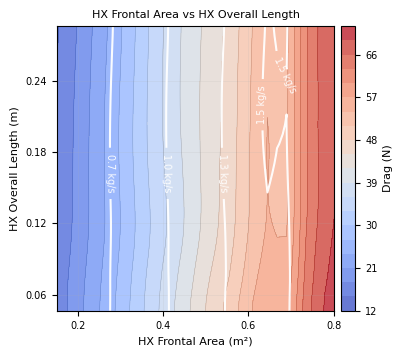


2. AS Hydraulic Diameter vs Aircraft Speed
GPU is available. Using GPU.
Calculating 30x30 grid for as_hyd vs aircraft_speed...
Saved plot as new/drag_heatmap_as_hyd_vs_aircraft_speed.png


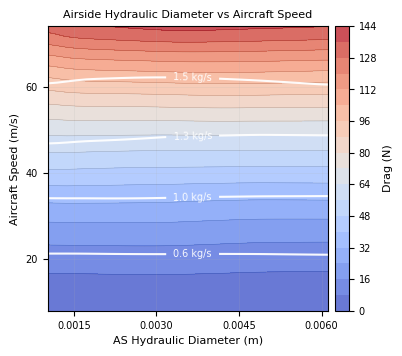


3. Area Ratio Nozzle vs Area Ratio Diffuser
GPU is available. Using GPU.
Calculating 30x30 grid for area_ratio_nozz vs area_ratio_diff...
Saved plot as new/drag_heatmap_area_ratio_nozz_vs_area_ratio_diff.png


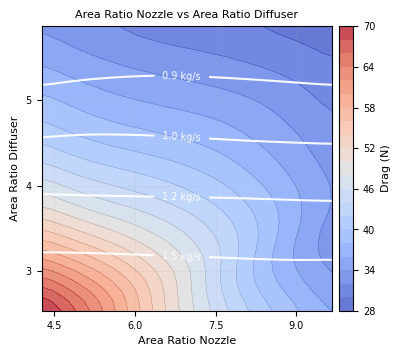


4. Area Ratio Diffuser vs Aircraft Speed
GPU is available. Using GPU.
Calculating 30x30 grid for area_ratio_diff vs aircraft_speed...
Saved plot as new/drag_heatmap_area_ratio_diff_vs_aircraft_speed.png


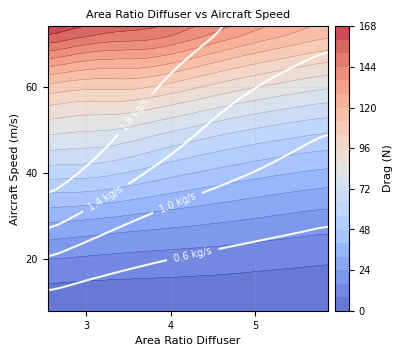


5. Porosity vs Strut Diameter
GPU is available. Using GPU.
Calculating 30x30 grid for strut_diam vs porosity...
Saved plot as new/drag_heatmap_strut_diam_vs_porosity.png


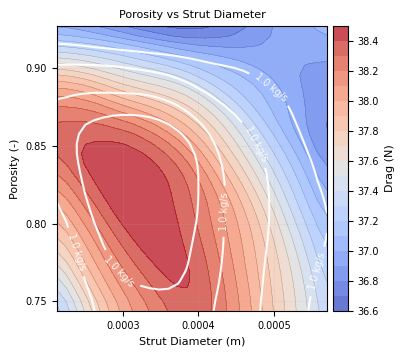


DRAG HEATMAP ANALYSIS COMPLETE
Generated 2D drag heatmaps showing:
• Color intensity represents Drag (N)
• White contour lines show constant Air Flow Rate levels
• Non-swept features held at median values

Coverage and projection summary:
  1) Frontal Area vs Length: 100.0% | projected points: 0
  2) AS Hyd Diameter vs Speed: 100.0% | projected points: 0
  3) Area Ratio Nozz vs Diff: 100.0% | projected points: 0
  4) Area Ratio Diff vs Speed: 100.0% | projected points: 0
  5) Porosity vs Strut Diameter: 100.0% | projected points: 0


In [78]:
# ============================================================================
# 2D Drag Heatmaps with Iso-Air-Flow Contours (projection-based, Power-style)
# ============================================================================
import numpy as np
import torch
import matplotlib.pyplot as plt
from scipy.optimize import minimize
import warnings
warnings.filterwarnings('ignore')
from scipy.ndimage import gaussian_filter
from matplotlib.ticker import MaxNLocator

DERIVED_FEATURES = {'frontal_area', 'porosity', 'as_hyd'}
DERIVED_TO_CALC_KEY = {
    'frontal_area': 'frontal_area',
    'porosity': 'porosity',
    'as_hyd': 'AS_hyd_diam',
}
DERIVED_CONTROL_VAR = {
    'porosity': [
        'Strut length to diameter ratio',
        'Strut Diameter (m)',
        'HX overall length (m)',
        'HX overall width (m)',
        'Channel height (m)',
        'Number of air layers/channels',
    ],
    'as_hyd': [
        'Strut Diameter (m)',
        'Strut length to diameter ratio',
        'HX overall length (m)',
        'HX overall width (m)',
        'Channel height (m)',
        'Number of air layers/channels',
    ],
    'frontal_area': [
        'HX overall width (m)',
        'Channel height (m)',
        'coolant channel diameter (m)',
        'Number of air layers/channels',
    ],
}
FEATURE_ALIASES = {
    'length': 'HX overall length (m)',
    'coolant_flow': 'coolant flow rate (kg/s)',
    'strut_ld': 'Strut length to diameter ratio',
    'strut_diam': 'Strut Diameter (m)',
    'area_ratio_diff': 'Area ratio_diff (diffuser exit/inlet)',
    'area_ratio_nozz': 'Area ratio_nozz (nozzle inlet/exit)',
    'aircraft_speed': 'aircraft speed',
}


def create_2d_drag_heatmap_with_isolines(
    best_result,
    feature_pair,
    grid_size=35,
    baseline_mode='median',
    fin_thickness=0.0002,
    aspect_mode='preserve_ratio',
    air_flow_contours=None,
    contour_tolerance=0.05,
    clamp_percentiles=(5, 95),
    show_data_points=False,
    cmap='coolwarm',
    save_plot=False,
    plot_title=None,
    solve_mode='auto',
    projection_reg=0.05,
    projection_rel_scale=0.02,
):
    """
    Create 2D drag heatmaps with iso-air-flow contours using strict solving with
    projected fallback (same methodology used in the Power notebook).

    solve_mode:
      - 'auto': strict for easy pairs (0-1 derived features), projected fallback for 2-derived pairs
      - 'strict': strict only
      - 'projected': always allow projected fallback
    """
    if not best_result:
        print('No model results available!')
        return None

    model = best_result['model']
    input_scaler = best_result['input_scaler']
    output_scaler = best_result['output_scaler']
    device = get_device()

    input_names = get_input_names()
    name_to_idx = {name: i for i, name in enumerate(input_names)}

    def resolve_feature_name(feat_name):
        if feat_name in DERIVED_FEATURES:
            return feat_name
        return FEATURE_ALIASES.get(feat_name, feat_name)

    feat1_raw, feat2_raw = feature_pair
    feat1_name = resolve_feature_name(feat1_raw)
    feat2_name = resolve_feature_name(feat2_raw)

    def need(n):
        if n not in name_to_idx:
            raise KeyError(f"Missing expected input: {n}")
        return name_to_idx[n]

    idx_coolant_diam = need('coolant channel diameter (m)')
    idx_overall_w = need('HX overall width (m)')
    idx_overall_l = need('HX overall length (m)')
    idx_channel_height = need('Channel height (m)')
    idx_num_layers = need('Number of air layers/channels')
    idx_strut_diam = need('Strut Diameter (m)')
    idx_strut_ld = need('Strut length to diameter ratio')
    idx_coolant_flow = need('coolant flow rate (kg/s)')
    idx_area_ratio_diff = need('Area ratio_diff (diffuser exit/inlet)')
    idx_area_ratio_nozz = need('Area ratio_nozz (nozzle inlet/exit)')
    idx_aircraft_speed = need('aircraft speed')

    x_mean = torch.tensor(input_scaler.mean_, dtype=torch.float32, device=device)
    x_scale = torch.tensor(input_scaler.scale_, dtype=torch.float32, device=device)
    y_mean = torch.tensor(output_scaler.mean_, dtype=torch.float32, device=device)
    y_scale = torch.tensor(output_scaler.scale_, dtype=torch.float32, device=device)

    x_low = np.percentile(X_data, clamp_percentiles[0], axis=0)
    x_high = np.percentile(X_data, clamp_percentiles[1], axis=0)

    if baseline_mode == 'median':
        x_baseline = np.percentile(X_data, 50, axis=0)
    elif baseline_mode == 'p25':
        x_baseline = np.percentile(X_data, 25, axis=0)
    elif baseline_mode == 'p75':
        x_baseline = np.percentile(X_data, 75, axis=0)
    else:
        x_baseline = np.percentile(X_data, 50, axis=0)

    derived_count = int(feat1_name in DERIVED_FEATURES) + int(feat2_name in DERIVED_FEATURES)
    if solve_mode == 'auto':
        # Strict is always attempted first; projected enables fallback for failed points.
        effective_mode = 'projected'
    else:
        effective_mode = solve_mode

    def _calc_feature_value(x, feat_name):
        if feat_name in DERIVED_FEATURES:
            key = DERIVED_TO_CALC_KEY[feat_name]
            return float(calc_derived_features(x)[key])
        return float(x[name_to_idx[feat_name]])

    def _robust_bounds(idx):
        lo, hi = np.percentile(X_data[:, idx], [1, 99])
        if not np.isfinite(lo) or not np.isfinite(hi) or hi <= lo:
            lo, hi = np.min(X_data[:, idx]), np.max(X_data[:, idx])
        return float(lo), float(hi)

    def _set_derived_feature(x, feature_name, target_value):
        x_new = x.copy()

        # All geometric features contributing to each derived feature
        _contributing = {
            'porosity': [
                'Strut length to diameter ratio',
                'Strut Diameter (m)',
                'HX overall length (m)',
                'HX overall width (m)',
                'Channel height (m)',
                'Number of air layers/channels',
            ],
            'as_hyd': [
                'Strut Diameter (m)',
                'Strut length to diameter ratio',
                'HX overall length (m)',
                'HX overall width (m)',
                'Channel height (m)',
                'Number of air layers/channels',
            ],
            'frontal_area': [
                'HX overall width (m)',
                'Channel height (m)',
                'coolant channel diameter (m)',
                'Number of air layers/channels',
            ],
        }

        ctrl_feature_names = [f for f in _contributing.get(feature_name, []) if f in name_to_idx]
        if not ctrl_feature_names:
            return x_new

        ctrl_idx = [name_to_idx[f] for f in ctrl_feature_names]
        bounds = []
        ctrl_scales = []
        x_ctrl0 = []
        for i in ctrl_idx:
            lo, hi = _robust_bounds(i)
            bounds.append((float(lo), float(hi)))
            ctrl_scales.append(max(hi - lo, 1e-12))
            x_ctrl0.append(float(x_new[i]))

        ctrl_scales = np.array(ctrl_scales, dtype=float)
        x_ctrl0 = np.array(x_ctrl0, dtype=float)

        derived_key = DERIVED_TO_CALC_KEY.get(feature_name, feature_name)

        def objective(v):
            x_trial = x_new.copy()
            for k, idx in enumerate(ctrl_idx):
                x_trial[idx] = float(v[k])
            actual = calc_derived_features(x_trial)[derived_key]
            s = max(abs(target_value) * 0.02, 1e-9)
            mismatch = ((actual - target_value) / s) ** 2
            delta = (v - x_ctrl0) / ctrl_scales
            return mismatch + 0.01 * float(np.dot(delta, delta))

        res = minimize(
            objective,
            x0=x_ctrl0,
            bounds=bounds,
            method='L-BFGS-B',
            options={'maxiter': 200, 'ftol': 1e-14},
        )

        v_opt = res.x if res.success else x_ctrl0
        for k, idx in enumerate(ctrl_idx):
            x_new[idx] = float(np.clip(v_opt[k], bounds[k][0], bounds[k][1]))

        return x_new
    def _is_target_achievable(x, feature_name, target_value, rel_tol=0.02, abs_tol=1e-8):
        actual = _calc_feature_value(x, feature_name)
        tol = max(abs_tol, rel_tol * max(abs(target_value), 1e-12))
        return np.isfinite(actual) and abs(actual - target_value) <= tol

    def _apply_feature_targets_strict(baseline_inputs, feature_targets):
        x = baseline_inputs.copy()

        for feature_name, target_val in feature_targets.items():
            if feature_name not in DERIVED_FEATURES:
                x[name_to_idx[feature_name]] = float(target_val)

        for derived_name in ['porosity', 'as_hyd', 'frontal_area']:
            if derived_name in feature_targets:
                x = _set_derived_feature(x, derived_name, float(feature_targets[derived_name]))

        return x

    def _project_to_targets_min_change(baseline_inputs, feature_targets, rel_scale=0.02, reg_lambda=0.05):
        x0 = baseline_inputs.copy()

        for feature_name, target_val in feature_targets.items():
            if feature_name not in DERIVED_FEATURES:
                x0[name_to_idx[feature_name]] = float(target_val)

        control_names = []
        for feature_name in feature_targets:
            if feature_name in DERIVED_FEATURES:
                ctrls = DERIVED_CONTROL_VAR.get(feature_name, [])
                for ctrl in ctrls:
                    if ctrl in name_to_idx:
                        control_names.append(ctrl)
        control_names = list(dict.fromkeys(control_names))

        if not control_names:
            return x0, {}

        ctrl_idx = [name_to_idx[n] for n in control_names]
        x_ctrl0 = np.array([x0[i] for i in ctrl_idx], dtype=float)

        bounds = []
        ctrl_scales = []
        for i in ctrl_idx:
            lo, hi = _robust_bounds(i)
            bounds.append((float(lo), float(hi)))
            ctrl_scales.append(max(hi - lo, 1e-12))
        ctrl_scales = np.array(ctrl_scales, dtype=float)

        target_items = [(k, float(v)) for k, v in feature_targets.items() if k in DERIVED_FEATURES]

        def objective(v):
            x = x0.copy()
            for k, idx in enumerate(ctrl_idx):
                x[idx] = float(v[k])

            mismatch = 0.0
            for feat, t in target_items:
                actual = _calc_feature_value(x, feat)
                s = max(abs(t) * rel_scale, 1e-9)
                mismatch += ((actual - t) / s) ** 2

            delta = (v - x_ctrl0) / ctrl_scales
            move_penalty = np.sum(delta * delta)
            return mismatch + reg_lambda * move_penalty

        res = minimize(
            objective,
            x0=x_ctrl0,
            bounds=bounds,
            method='L-BFGS-B',
            options={'maxiter': 120, 'ftol': 1e-12},
        )

        v_opt = res.x if res.success else x_ctrl0
        x_opt = x0.copy()
        for k, idx in enumerate(ctrl_idx):
            x_opt[idx] = float(v_opt[k])

        achieved = {}
        for feat, t in target_items:
            achieved[feat] = {'target': t, 'actual': _calc_feature_value(x_opt, feat)}

        return x_opt, achieved

    def predict_drag_heatload_airflow(x_input):
        x_tensor = torch.tensor(x_input, dtype=torch.float32, device=device)
        x_scaled = (x_tensor - x_mean) / x_scale

        with torch.no_grad():
            y_scaled = model(x_scaled.unsqueeze(0))

        y_real = y_scaled * y_scale + y_mean
        drag = float(y_real[0, 0].item())
        heat_load = float(y_real[0, 1].item())
        air_flow = float(y_real[0, 2].item())
        return drag, heat_load, air_flow

    def _feature_range_and_label(feat_name):
        if feat_name == 'as_hyd':
            vals = np.array([calc_derived_features(row)['AS_hyd_diam'] for row in X_data], dtype=float)
            return np.percentile(vals, clamp_percentiles[0]), np.percentile(vals, clamp_percentiles[1]), 'AS Hydraulic Diameter (m)'
        if feat_name == 'frontal_area':
            vals = np.array([calc_derived_features(row)['frontal_area'] for row in X_data], dtype=float)
            return np.percentile(vals, clamp_percentiles[0]), np.percentile(vals, clamp_percentiles[1]), 'HX Frontal Area (m²)'
        if feat_name == 'porosity':
            vals = np.array([calc_derived_features(row)['porosity'] for row in X_data], dtype=float)
            return np.percentile(vals, clamp_percentiles[0]), np.percentile(vals, clamp_percentiles[1]), 'Porosity (-)'
        if feat_name == 'Strut length to diameter ratio':
            return x_low[idx_strut_ld], x_high[idx_strut_ld], 'Strut L/D Ratio (-)'
        if feat_name == 'coolant flow rate (kg/s)':
            return x_low[idx_coolant_flow], x_high[idx_coolant_flow], 'Coolant Flow Rate (kg/s)'
        if feat_name == 'HX overall length (m)':
            return x_low[idx_overall_l], x_high[idx_overall_l], 'HX Overall Length (m)'
        if feat_name == 'Area ratio_diff (diffuser exit/inlet)':
            return x_low[idx_area_ratio_diff], x_high[idx_area_ratio_diff], 'Area Ratio Diffuser'
        if feat_name == 'Area ratio_nozz (nozzle inlet/exit)':
            return x_low[idx_area_ratio_nozz], x_high[idx_area_ratio_nozz], 'Area Ratio Nozzle'
        if feat_name == 'aircraft speed':
            return x_low[idx_aircraft_speed], x_high[idx_aircraft_speed], 'Aircraft Speed (m/s)'
        if feat_name == 'Strut Diameter (m)':
            return x_low[idx_strut_diam], x_high[idx_strut_diam], 'Strut Diameter (m)'
        raise ValueError(f'Unknown feature: {feat_name}')

    feat1_min, feat1_max, feat1_label = _feature_range_and_label(feat1_name)
    feat2_min, feat2_max, feat2_label = _feature_range_and_label(feat2_name)

    feat1_grid = np.linspace(feat1_min, feat1_max, grid_size)
    feat2_grid = np.linspace(feat2_min, feat2_max, grid_size)
    F1, F2 = np.meshgrid(feat1_grid, feat2_grid)

    drag_grid = np.full_like(F1, np.nan, dtype=float)
    heatload_grid = np.full_like(F1, np.nan, dtype=float)
    airflow_grid = np.full_like(F1, np.nan, dtype=float)

    successful_points = 0
    projected_points = 0

    # Use gentler fallback projection for easier (0-1 derived feature) pairs.
    if derived_count <= 1:
        local_projection_reg = max(0.01, 0.5 * projection_reg)
        local_projection_rel_scale = max(0.01, 0.7 * projection_rel_scale)
    else:
        local_projection_reg = projection_reg
        local_projection_rel_scale = projection_rel_scale

    print(f'Calculating {grid_size}x{grid_size} grid for {feat1_raw} vs {feat2_raw}...')

    for i in range(grid_size):
        for j in range(grid_size):
            try:
                baseline_inputs = x_baseline.copy()
                feature_targets = {feat1_name: float(F1[i, j]), feat2_name: float(F2[i, j])}

                x_point = _apply_feature_targets_strict(baseline_inputs, feature_targets)

                drag, heat_load, air_flow = predict_drag_heatload_airflow(x_point)
                drag_grid[i, j] = drag
                heatload_grid[i, j] = heat_load
                airflow_grid[i, j] = air_flow
                successful_points += 1

            except Exception:
                if effective_mode == 'projected':
                    try:
                        x_point, _ = _project_to_targets_min_change(
                            baseline_inputs, feature_targets,
                            rel_scale=local_projection_rel_scale,
                            reg_lambda=local_projection_reg,
                        )
                        drag, heat_load, air_flow = predict_drag_heatload_airflow(x_point)
                        drag_grid[i, j] = drag
                        heatload_grid[i, j] = heat_load
                        airflow_grid[i, j] = air_flow
                        successful_points += 1
                        projected_points += 1
                    except Exception:
                        pass

    coverage_pct = 100.0 * successful_points / max(grid_size * grid_size, 1)

    # Smooth grids to reduce optimizer-induced spiking
    for _g in [drag_grid, heatload_grid, airflow_grid]:
        _mask = np.isnan(_g)
        if not _mask.all():
            _g[_mask] = np.nanmean(_g)
            _g[:] = gaussian_filter(_g, sigma=1.0)
            _g[_mask] = np.nan

    if air_flow_contours is None:
        af_valid = airflow_grid[~np.isnan(airflow_grid)]
        if len(af_valid) > 0:
            percentiles = np.percentile(af_valid, [20, 40, 60, 80])
            air_flow_contours = np.unique(percentiles)
            if len(air_flow_contours) < 2:
                air_flow_contours = np.linspace(np.min(af_valid), np.max(af_valid), 4)[1:-1]
            air_flow_contours = np.sort(air_flow_contours)
        else:
            air_flow_contours = []

    fig, ax = plt.subplots(1, 1, figsize=(4, 3.5))

    im = ax.contourf(F1, F2, drag_grid, levels=20, cmap=cmap, alpha=0.8)
    ax.contour(F1, F2, drag_grid, levels=20, colors='k', linewidths=0.3, linestyles='solid', alpha=0.25)

    cbar = plt.colorbar(im, ax=ax, pad=0.02)
    cbar.set_label('Drag (N)', fontsize=8)
    cbar.ax.tick_params(labelsize=7)

    if len(air_flow_contours) > 0:
        air_flow_contours = np.array(air_flow_contours)
        air_flow_contours = air_flow_contours[~np.isnan(air_flow_contours)]
        air_flow_contours = np.unique(air_flow_contours)
        air_flow_contours = np.sort(air_flow_contours)

        af_min, af_max = np.nanmin(airflow_grid), np.nanmax(airflow_grid)
        valid_contours = air_flow_contours[(air_flow_contours > af_min) & (air_flow_contours < af_max)]

        if len(valid_contours) >= 2 and np.all(np.diff(valid_contours) > 0):
            try:
                cs = ax.contour(F1, F2, airflow_grid, levels=valid_contours, colors='white', linewidths=1.5, alpha=0.95)
                clabels = ax.clabel(cs, inline=True, fontsize=7, fmt='%.1f kg/s')
            except Exception as e:
                print(f'Warning: Could not draw air flow contours: {e}')
        else:
            print(f'Warning: Invalid contour levels. Range: [{af_min:.3f}, {af_max:.3f}], Levels: {valid_contours}')

    if show_data_points:
        sample_idx = np.arange(0, len(X_data), 20)

        if feat1_name == 'frontal_area' and feat2_name == 'HX overall length (m)':
            area_data_pts = np.array([calc_derived_features(X_data[i])['frontal_area'] for i in sample_idx])
            len_data_pts = X_data[sample_idx, idx_overall_l]
            ax.scatter(area_data_pts, len_data_pts, c='red', s=4, alpha=0.4,
                       edgecolors='darkred', linewidth=0.3, label=f'Data Points (n={len(sample_idx)})')
        elif feat1_name == 'as_hyd' and feat2_name == 'aircraft speed':
            hyd_data_pts = np.array([calc_derived_features(X_data[i])['AS_hyd_diam'] for i in sample_idx])
            speed_data_pts = X_data[sample_idx, idx_aircraft_speed]
            ax.scatter(hyd_data_pts, speed_data_pts, c='red', s=4, alpha=0.4,
                       edgecolors='darkred', linewidth=0.3, label=f'Data Points (n={len(sample_idx)})')
        elif feat1_name == 'Area ratio_nozz (nozzle inlet/exit)' and feat2_name == 'Area ratio_diff (diffuser exit/inlet)':
            nozz_data_pts = X_data[sample_idx, idx_area_ratio_nozz]
            diff_data_pts = X_data[sample_idx, idx_area_ratio_diff]
            ax.scatter(nozz_data_pts, diff_data_pts, c='red', s=4, alpha=0.4,
                       edgecolors='darkred', linewidth=0.3, label=f'Data Points (n={len(sample_idx)})')
        elif feat1_name == 'Area ratio_diff (diffuser exit/inlet)' and feat2_name == 'aircraft speed':
            diff_data_pts = X_data[sample_idx, idx_area_ratio_diff]
            speed_data_pts = X_data[sample_idx, idx_aircraft_speed]
            ax.scatter(diff_data_pts, speed_data_pts, c='red', s=4, alpha=0.4,
                       edgecolors='darkred', linewidth=0.3, label=f'Data Points (n={len(sample_idx)})')

    ax.set_xlabel(feat1_label, fontsize=8)
    ax.set_ylabel(feat2_label, fontsize=8)

    if plot_title is not None:
        ax.set_title(plot_title, fontsize=8)

    ax.tick_params(axis='both', labelsize=7)
    ax.xaxis.set_major_locator(MaxNLocator(nbins=4, prune='both'))
    ax.yaxis.set_major_locator(MaxNLocator(nbins=4, prune='both'))
    ax.grid(True, alpha=0.2, linewidth=0.5)

    if show_data_points:
        ax.legend(fontsize=7)

    plt.tight_layout(pad=0.5)

    if save_plot:
        filename = f'new/drag_heatmap_{feat1_raw}_vs_{feat2_raw}.png'
        plt.savefig(filename, dpi=300, bbox_inches='tight')
        print(f'Saved plot as {filename}')

    plt.show()

    return {
        'feature_pair': (feat1_raw, feat2_raw),
        'feat1_grid': F1,
        'feat2_grid': F2,
        'drag_grid': drag_grid,
        'heatload_grid': heatload_grid,
        'airflow_grid': airflow_grid,
        'air_flow_contours': air_flow_contours,
        'feat1_label': feat1_label,
        'feat2_label': feat2_label,
        'coverage_percentage': coverage_pct,
        'successful_points': successful_points,
        'projected_points': projected_points,
        'solve_mode': effective_mode,
    }


# ============================================================================
# Generate the requested Drag heatmaps
# ============================================================================

print('Generating 2D Drag Heatmaps with Iso-Air-Flow Contours...')
print('=' * 70)

# Use auto mode: strict where feasible, projected fallback only when needed
solve_mode = 'auto'
projection_reg = 0.25
projection_rel_scale = 0.1

# 1. HX Frontal Area vs HX overall length (HX3 version)
print('\n1. HX Frontal Area vs HX Overall Length')
result1 = create_2d_drag_heatmap_with_isolines(
    best_result,
    feature_pair=('frontal_area', 'length'),
    grid_size=30,
    baseline_mode='median',
    show_data_points=False,
    save_plot=True,
    plot_title='HX Frontal Area vs HX Overall Length',
    solve_mode=solve_mode,
    projection_reg=projection_reg,
    projection_rel_scale=projection_rel_scale,
)

# 2. Airside hydraulic diameter vs Aircraft speed (HX3 version)
print('\n2. AS Hydraulic Diameter vs Aircraft Speed')
result2 = create_2d_drag_heatmap_with_isolines(
    best_result,
    feature_pair=('as_hyd', 'aircraft_speed'),
    grid_size=30,
    baseline_mode='median',
    show_data_points=False,
    save_plot=True,
    plot_title='Airside Hydraulic Diameter vs Aircraft Speed',
    solve_mode=solve_mode,
    projection_reg=projection_reg,
    projection_rel_scale=projection_rel_scale,
)

# 3. Area ratio nozzle vs Area ratio diffuser
print('\n3. Area Ratio Nozzle vs Area Ratio Diffuser')
result3 = create_2d_drag_heatmap_with_isolines(
    best_result,
    feature_pair=('area_ratio_nozz', 'area_ratio_diff'),
    grid_size=30,
    baseline_mode='median',
    show_data_points=False,
    save_plot=True,
    plot_title='Area Ratio Nozzle vs Area Ratio Diffuser',
    solve_mode=solve_mode,
    projection_reg=projection_reg,
    projection_rel_scale=projection_rel_scale,
)

# 4. Area ratio diffuser vs Aircraft speed
print('\n4. Area Ratio Diffuser vs Aircraft Speed')
result4 = create_2d_drag_heatmap_with_isolines(
    best_result,
    feature_pair=('area_ratio_diff', 'aircraft_speed'),
    grid_size=30,
    baseline_mode='median',
    show_data_points=False,
    save_plot=True,
    plot_title='Area Ratio Diffuser vs Aircraft Speed',
    solve_mode=solve_mode,
    projection_reg=projection_reg,
    projection_rel_scale=projection_rel_scale,
)

# 5. Porosity vs Strut Diameter
print('\n5. Porosity vs Strut Diameter')
result5 = create_2d_drag_heatmap_with_isolines(
    best_result,
    feature_pair=('strut_diam', 'porosity'),
    grid_size=30,
    baseline_mode='median',
    show_data_points=False,
    save_plot=True,
    plot_title='Porosity vs Strut Diameter',
    solve_mode=solve_mode,
    projection_reg=projection_reg,
    projection_rel_scale=projection_rel_scale,
)

print('\n' + '=' * 70)
print('DRAG HEATMAP ANALYSIS COMPLETE')
print('=' * 70)
print('Generated 2D drag heatmaps showing:')
print('• Color intensity represents Drag (N)')
print('• White contour lines show constant Air Flow Rate levels')
print('• Non-swept features held at median values')
print('\nCoverage and projection summary:')
print(f"  1) Frontal Area vs Length: {result1['coverage_percentage']:.1f}% | projected points: {result1['projected_points']}")
print(f"  2) AS Hyd Diameter vs Speed: {result2['coverage_percentage']:.1f}% | projected points: {result2['projected_points']}")
print(f"  3) Area Ratio Nozz vs Diff: {result3['coverage_percentage']:.1f}% | projected points: {result3['projected_points']}")
print(f"  4) Area Ratio Diff vs Speed: {result4['coverage_percentage']:.1f}% | projected points: {result4['projected_points']}")
print(f"  5) Porosity vs Strut Diameter: {result5['coverage_percentage']:.1f}% | projected points: {result5['projected_points']}")

In [79]:
# Diagnostic: check airflow variation for porosity vs strut diameter context
import numpy as np

# Use same filtered data already loaded in notebook: X_data, y_data
# y_data columns: [Drag, Heat Load, Air flow rate]
airflow = y_data[:, 2]

# Recompute porosity from X_data using same formula as calc_derived_features
porosity_vals = np.array([calc_derived_features(row)['porosity'] for row in X_data], dtype=float)
strut_diam_vals = X_data[:, get_input_names().index('Strut Diameter (m)')]

print('N =', len(X_data))
print('Airflow min/median/max =', np.min(airflow), np.median(airflow), np.max(airflow))
print('Airflow p5/p95 =', np.percentile(airflow, 5), np.percentile(airflow, 95))
print('Airflow std =', np.std(airflow))
print('Corr(airflow, porosity) =', np.corrcoef(airflow, porosity_vals)[0,1])
print('Corr(airflow, strut_diam) =', np.corrcoef(airflow, strut_diam_vals)[0,1])

N = 59832
Airflow min/median/max = 0.01319783696446693 0.9577623578125356 7.457322313207631
Airflow p5/p95 = 0.18666837940044909 2.706132319190288
Airflow std = 0.8114150309021887
Corr(airflow, porosity) = 0.10371325990099226
Corr(airflow, strut_diam) = 0.06111073825342584


In [80]:
# Diagnostic: inspect airflow grid used in Porosity vs Strut Diameter heatmap
if 'result5' in globals() and isinstance(result5, dict) and 'airflow_grid' in result5:
    af = result5['airflow_grid']
    af_valid = af[np.isfinite(af)]
    print('result5 airflow valid points =', af_valid.size)
    if af_valid.size > 0:
        print('result5 airflow min/median/max =', np.min(af_valid), np.median(af_valid), np.max(af_valid))
        print('result5 airflow p10/p90 =', np.percentile(af_valid, 10), np.percentile(af_valid, 90))
else:
    print('result5 not found yet. Re-run the heatmap generation cell first.')

result5 airflow valid points = 900
result5 airflow min/median/max = 0.989168841023696 1.0044678969924155 1.0110091994305586
result5 airflow p10/p90 = 0.994336344946031 1.0096420012549852


In [81]:
# Diagnostic: inspect drag and heat variation in result5
if 'result5' in globals() and isinstance(result5, dict):
    for k in ['drag_grid', 'heatload_grid']:
        if k in result5:
            vv = result5[k]
            vv = vv[np.isfinite(vv)]
            if vv.size:
                print(k, 'min/median/max =', np.min(vv), np.median(vv), np.max(vv))
                print(k, 'p10/p90 =', np.percentile(vv, 10), np.percentile(vv, 90))
    if 'coverage_percentage' in result5:
        print('coverage =', result5['coverage_percentage'])
    if 'projected_points' in result5:
        print('projected_points =', result5['projected_points'])

drag_grid min/median/max = 36.671177933110236 37.77614171874504 38.487230044795595
drag_grid p10/p90 = 36.92854070899106 38.395623123587924
heatload_grid min/median/max = 21737.086344281237 24657.341695783492 25233.59674212555
heatload_grid p10/p90 = 23413.125424420283 25094.645428086737
coverage = 100.0
projected_points = 0
